In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split


In [2]:
df_cust = pd.read_csv('customers.csv')
df_loan = pd.read_csv('loans.csv')
df_bureau = pd.read_csv('bureau_data.csv')

In [3]:
df_cust.shape,df_loan.shape,df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [4]:
df_cust.head(2)

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001


In [5]:
df_loan.head(2)

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False


In [6]:
df_bureau.head(2)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4


In [7]:
df =pd.merge(df_cust,df_loan,on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [8]:
df =pd.merge(df,df_bureau,on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [9]:
df.shape

(50000, 33)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [11]:
df['default'] = df['default'].astype(np.int32)
df['default'].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [12]:
import numpy as np

df['default'] = df['default'].astype(np.int32)


In [13]:
print(df['default'].dtype)


int32


In [14]:
X = df.drop('default',axis=1)
y = df['default']


# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

df_train = pd.concat([X_train,y_train],axis='columns')
df_test = pd.concat([X_test,y_test],axis='columns')

# Here, test_size=0.2 means 20% of the data will be used for testing,
# and random_state=42 ensures reproducibility of the split.

# Optionally, you can print the shapes of the resulting datasets to verify
print("Shape of df_train:", df_train.shape)
print("Shape of df_test:", df_test.shape)


Shape of df_train: (37500, 33)
Shape of df_test: (12500, 33)


In [15]:
df.isnull().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 62
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
default                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_mon

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [17]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [18]:
mode_residence =df_train['residence_type'].mode()[0]
mode_residence 

'Owned'

In [19]:
df_train.residence_type.fillna(mode_residence,inplace=True)
            

C:\Users\Admin\AppData\Local\Temp\ipykernel_10700\1436658984.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train.residence_type.fillna(mode_residence,inplace=True)


In [20]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [21]:
df_test.residence_type.fillna(mode_residence,inplace=True)
df_test.residence_type.unique()

C:\Users\Admin\AppData\Local\Temp\ipykernel_10700\423004563.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test.residence_type.fillna(mode_residence,inplace=True)


array(['Owned', 'Rented', 'Mortgage'], dtype=object)

In [22]:
df_train.duplicated().sum()

0

In [23]:
Columns_numeric = df_train.select_dtypes('int64','float64').columns
Columns_numeric

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'sanction_amount', 'loan_amount', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio'],
      dtype='object')

In [24]:
columns_categorical = df_train.select_dtypes('object').columns
columns_categorical

Index(['cust_id', 'gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'loan_id', 'loan_purpose',
       'loan_type', 'disbursal_date', 'installment_start_dt'],
      dtype='object')

In [25]:
categorical_col = [ 'gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'loan_purpose','zipcode',
       'loan_type', 'default']

continuous_col =['age', 'income', 'number_of_dependants', 'years_at_current_address',
        'sanction_amount', 'loan_amount', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding','processing_fee',                
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

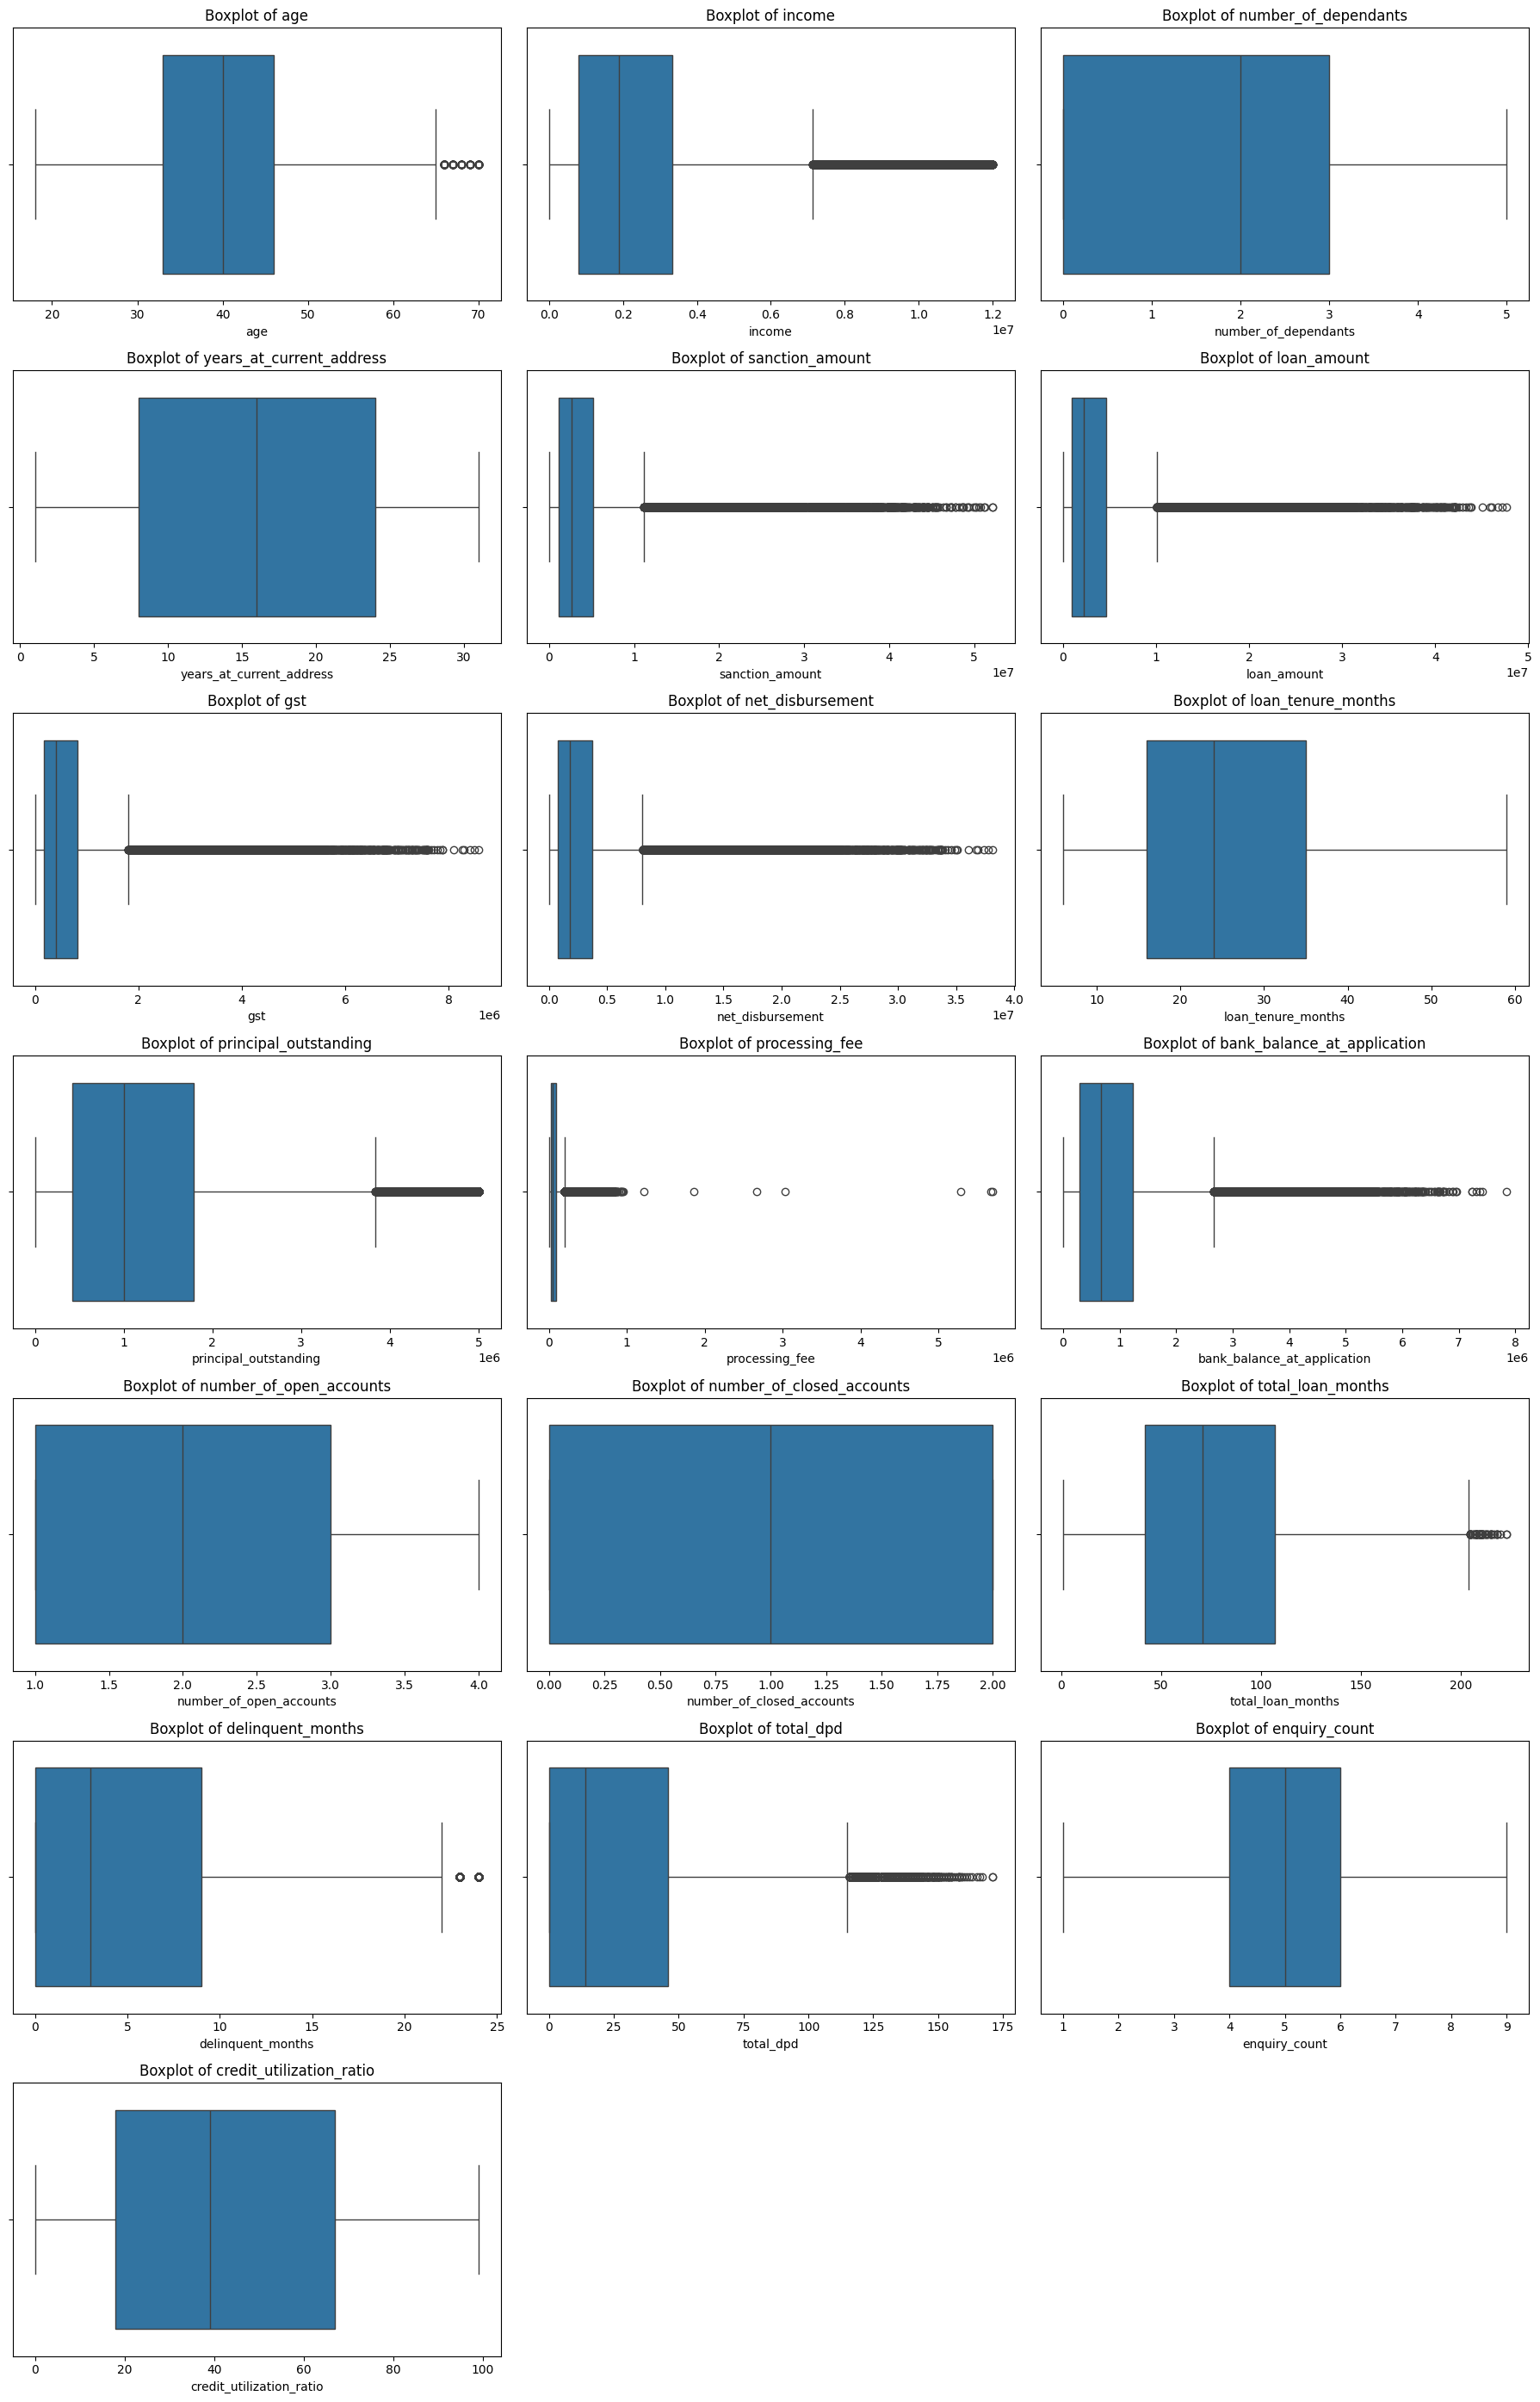

In [26]:
import math

n = len(continuous_col)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_col):
    sns.boxplot(data=df_train, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

# Remove extra axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

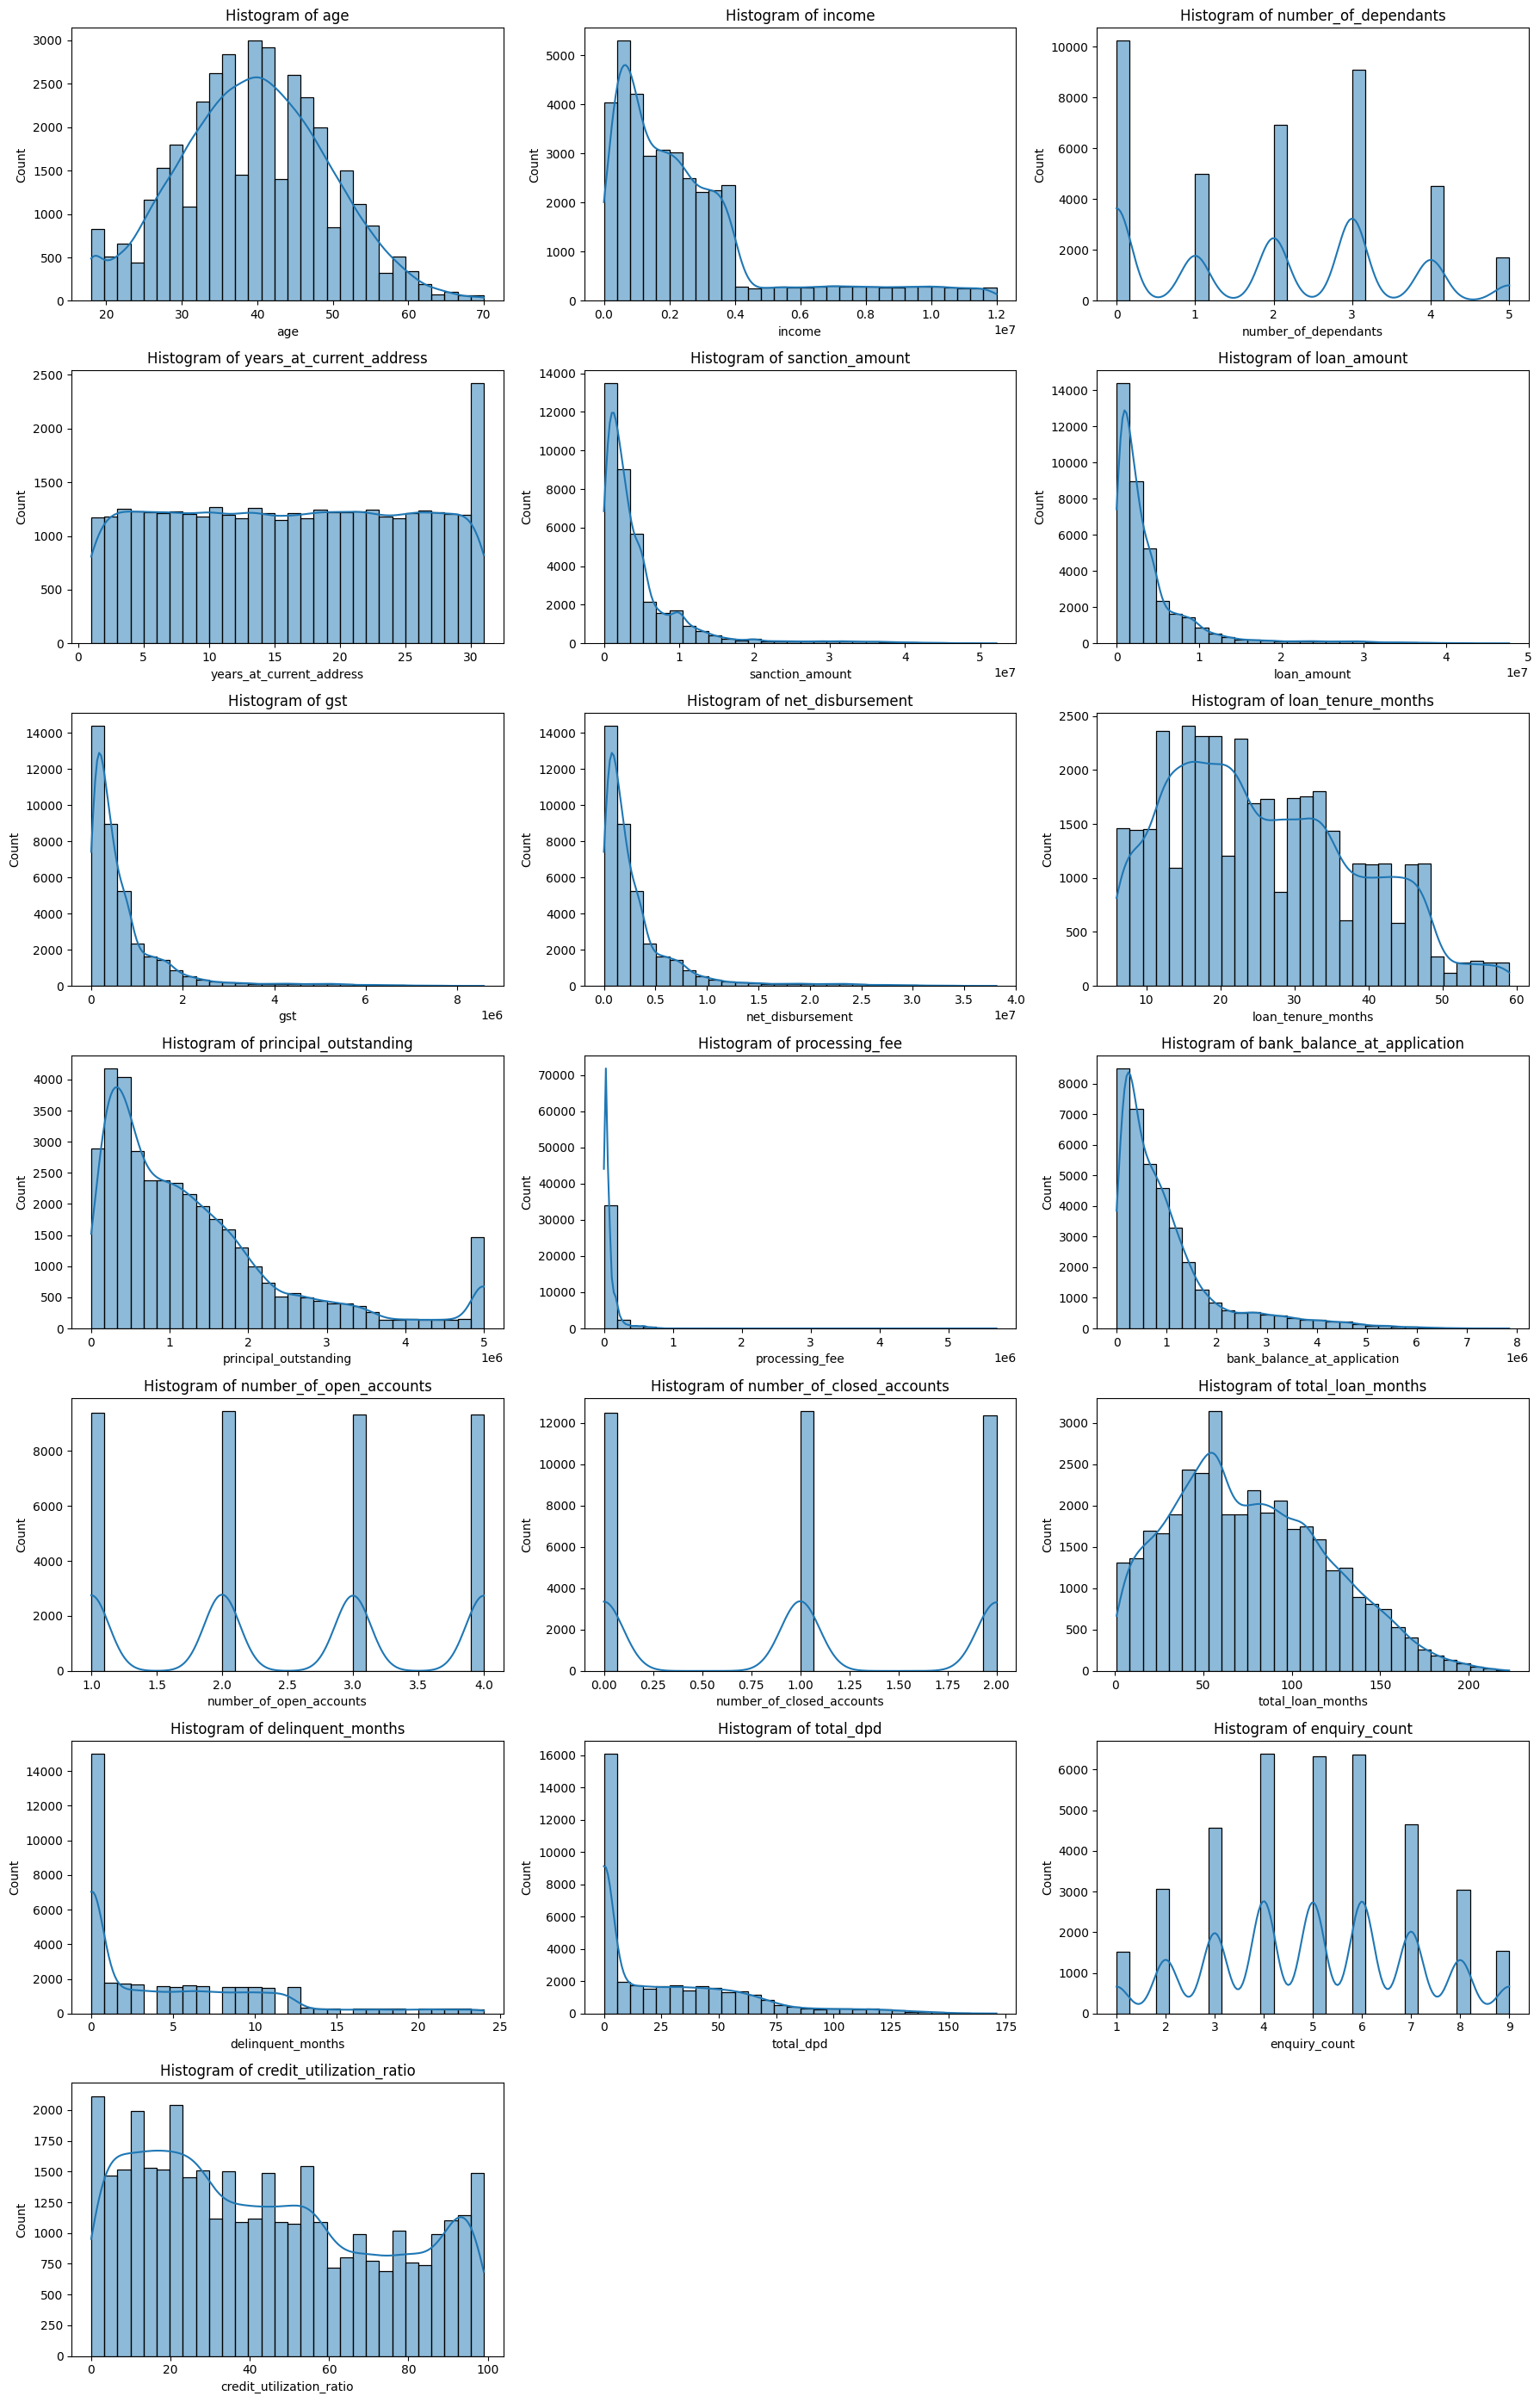

In [27]:
import math

n = len(continuous_col)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_col):
    sns.histplot(data=df_train, x=col, ax=axes[i], bins=30, kde=True)
    axes[i].set_title(f'Histogram of {col}')

# Remove extra axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [28]:
# Turn off scientific notation
pd.set_option('display.float_format', '{:,.2f}'.format)

# Now describe
df_train.describe()


,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
count,"37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00",...,"37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00","37,500.00"
mean,39.56,"2,636,054.83",1.94,15.99,"418,768.57","4,706,706.56","4,002,796.64","80,724.11","720,503.40","3,202,237.31",...,"1,336,077.19","987,467.44",2.50,1.00,76.00,4.89,26.94,5.00,43.33,0.09
std,9.85,"2,624,140.92",1.54,8.94,"168,831.82","6,288,692.94","5,400,902.41","120,830.65","972,162.43","4,320,721.92",...,"1,213,733.93","1,045,108.58",1.12,0.82,43.71,5.86,32.93,2.02,29.36,0.28
min,18.00,0.00,0.00,1.00,"110,001.00",0.00,0.00,0.00,0.00,0.00,...,-1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
25%,33.00,"803,000.00",0.00,8.00,"302,001.00","1,136,000.00","959,000.00","19,180.00","172,620.00","767,200.00",...,"423,931.00","286,189.50",1.00,0.00,42.00,0.00,0.00,4.00,18.00,0.00
50%,40.00,"1,884,000.00",2.00,16.00,"400,001.00","2,651,000.00","2,234,000.00","44,700.00","402,120.00","1,787,200.00",...,"1,000,881.50","666,825.00",2.00,1.00,71.00,3.00,14.00,5.00,39.00,0.00
75%,46.00,"3,332,000.00",3.00,24.00,"560,001.00","5,159,000.00","4,597,250.00","92,000.00","827,505.00","3,677,800.00",...,"1,789,091.75","1,236,740.50",3.00,2.00,107.00,9.00,46.00,6.00,67.00,0.00
max,70.00,"11,999,000.00",5.00,31.00,"700,001.00","52,175,000.00","47,667,000.00","5,698,029.90","8,580,060.00","38,133,600.00",...,"5,000,000.00","7,846,643.00",4.00,2.00,223.00,24.00,171.00,9.00,99.00,1.00


In [29]:
df_train[(df_train.processing_fee/df_train.loan_amount)>0.03][['loan_amount','processing_fee']]

,loan_amount,processing_fee
23981,2234000,"2,669,791.02"
9898,3626000,"5,293,543.52"
47089,1738000,"1,858,964.77"
33705,3812000,"5,678,020.86"
12294,4639000,"5,698,029.90"
28174,966000,"1,214,492.67"
29305,2616000,"3,036,378.01"


In [30]:
df_train1 = df_train[(df_train.processing_fee/df_train.loan_amount)<0.03].copy()

                                                                               

In [31]:
df_train1.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
count,"37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00",...,"37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00"
mean,39.56,"2,636,119.11",1.94,15.99,"418,763.45","4,707,707.29","4,003,661.08","80,073.22","720,658.99","3,202,928.87",...,"1,336,226.34","987,509.19",2.50,1.00,75.99,4.89,26.94,5.00,43.33,0.09
std,9.85,"2,623,816.51",1.54,8.94,"168,837.51","6,289,437.60","5,401,552.03","108,031.04","972,279.36","4,321,241.62",...,"1,213,772.91","1,044,992.95",1.12,0.82,43.71,5.86,32.93,2.02,29.36,0.28
min,18.00,"100,000.00",0.00,1.00,"110,001.00","71,000.00","50,000.00","1,000.00","9,000.00","40,000.00",...,"35,999.00","19,415.00",1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
25%,33.00,"803,000.00",0.00,8.00,"302,001.00","1,136,000.00","959,500.00","19,190.00","172,710.00","767,600.00",...,"424,079.00","286,231.50",1.00,0.00,42.00,0.00,0.00,4.00,18.00,0.00
50%,40.00,"1,884,000.00",2.00,16.00,"400,001.00","2,652,000.00","2,235,000.00","44,700.00","402,300.00","1,788,000.00",...,"1,000,924.00","666,885.00",2.00,1.00,71.00,3.00,14.00,5.00,39.00,0.00
75%,46.00,"3,331,500.00",3.00,24.00,"560,001.00","5,159,500.00","4,598,000.00","91,960.00","827,640.00","3,678,400.00",...,"1,789,047.00","1,236,742.00",3.00,2.00,107.00,9.00,46.00,6.00,67.00,0.00
max,70.00,"11,999,000.00",5.00,31.00,"700,001.00","52,175,000.00","47,667,000.00","953,340.00","8,580,060.00","38,133,600.00",...,"5,000,000.00","7,846,643.00",4.00,2.00,223.00,24.00,171.00,9.00,99.00,1.00


In [32]:
df_test.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
count,"12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00",...,"12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00","12,500.00"
mean,39.51,"2,655,425.52",1.93,16.09,"420,057.72","4,699,190.40","3,990,325.28","79,806.51","718,258.55","3,192,260.22",...,"1,342,312.57","994,103.21",2.51,1.01,76.51,4.84,26.62,5.03,43.46,0.09
std,9.83,"2,645,329.94",1.53,8.89,"169,437.51","6,202,829.52","5,303,033.17","106,060.66","954,545.97","4,242,426.54",...,"1,217,685.72","1,048,982.65",1.12,0.81,43.93,5.81,32.55,2.04,29.36,0.28
min,18.00,0.00,0.00,1.00,"110,001.00",0.00,0.00,0.00,0.00,0.00,...,-1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
25%,33.00,"804,750.00",0.00,8.00,"302,001.00","1,174,750.00","989,000.00","19,780.00","178,020.00","791,200.00",...,"427,161.25","289,406.50",1.00,0.00,43.00,0.00,0.00,4.00,18.00,0.00
50%,40.00,"1,916,000.00",2.00,16.00,"411,001.00","2,669,000.00","2,251,000.00","45,020.00","405,180.00","1,800,800.00",...,"1,005,422.00","673,471.50",3.00,1.00,72.00,3.00,14.00,5.00,39.00,0.00
75%,46.00,"3,336,250.00",3.00,24.00,"560,001.00","5,233,500.00","4,652,750.00","93,055.00","837,495.00","3,722,200.00",...,"1,796,377.25","1,245,145.00",4.00,2.00,107.00,8.00,46.00,7.00,67.00,0.00
max,70.00,"11,990,000.00",5.00,31.00,"700,001.00","49,622,000.00","47,819,000.00","956,380.00","8,607,420.00","38,255,200.00",...,"5,000,000.00","6,903,073.00",4.00,2.00,221.00,24.00,162.00,9.00,99.00,1.00


In [33]:
df_test[(df_test.processing_fee/df_test.loan_amount)>0.03][['loan_amount','processing_fee']]

,loan_amount,processing_fee


In [34]:
df_test = df_test[(df_test.processing_fee/df_test.loan_amount)<0.03].copy()

In [35]:
for col in categorical_col:
    print(col,'--->',df_train1[col].unique())

gender ---> ['F' 'M']
marital_status ---> ['Single' 'Married']
employment_status ---> ['Salaried' 'Self-Employed']
residence_type ---> ['Owned' 'Mortgage' 'Rented']
city ---> ['Ahmedabad' 'Delhi' 'Lucknow' 'Bangalore' 'Jaipur' 'Hyderabad' 'Kolkata'
 'Pune' 'Chennai' 'Mumbai']
state ---> ['Gujarat' 'Delhi' 'Uttar Pradesh' 'Karnataka' 'Rajasthan' 'Telangana'
 'West Bengal' 'Maharashtra' 'Tamil Nadu']
loan_purpose ---> ['Home' 'Auto' 'Personal' 'Education' 'Personaal']
zipcode ---> [380001 110001 226001 560001 302001 500001 700001 411001 600001 400001]
loan_type ---> ['Secured' 'Unsecured']
default ---> [0 1]


In [36]:
df_train1['loan_purpose'] = df_train1['loan_purpose'].replace({'Personaal': 'Personal'})

In [37]:
df_train1.loan_purpose.unique()

array(['Home', 'Auto', 'Personal', 'Education'], dtype=object)

In [38]:
df_test['loan_purpose'] = df_test['loan_purpose'].replace({'Personaal': 'Personal'})

In [39]:
df_train1[(df_train1.gst/df_train1.loan_amount)>.18]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default


In [40]:
df_train1.shape

(37487, 33)

<h2 style="color:blue">📊 Exploratory Data Analysis (EDA)</h2>


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


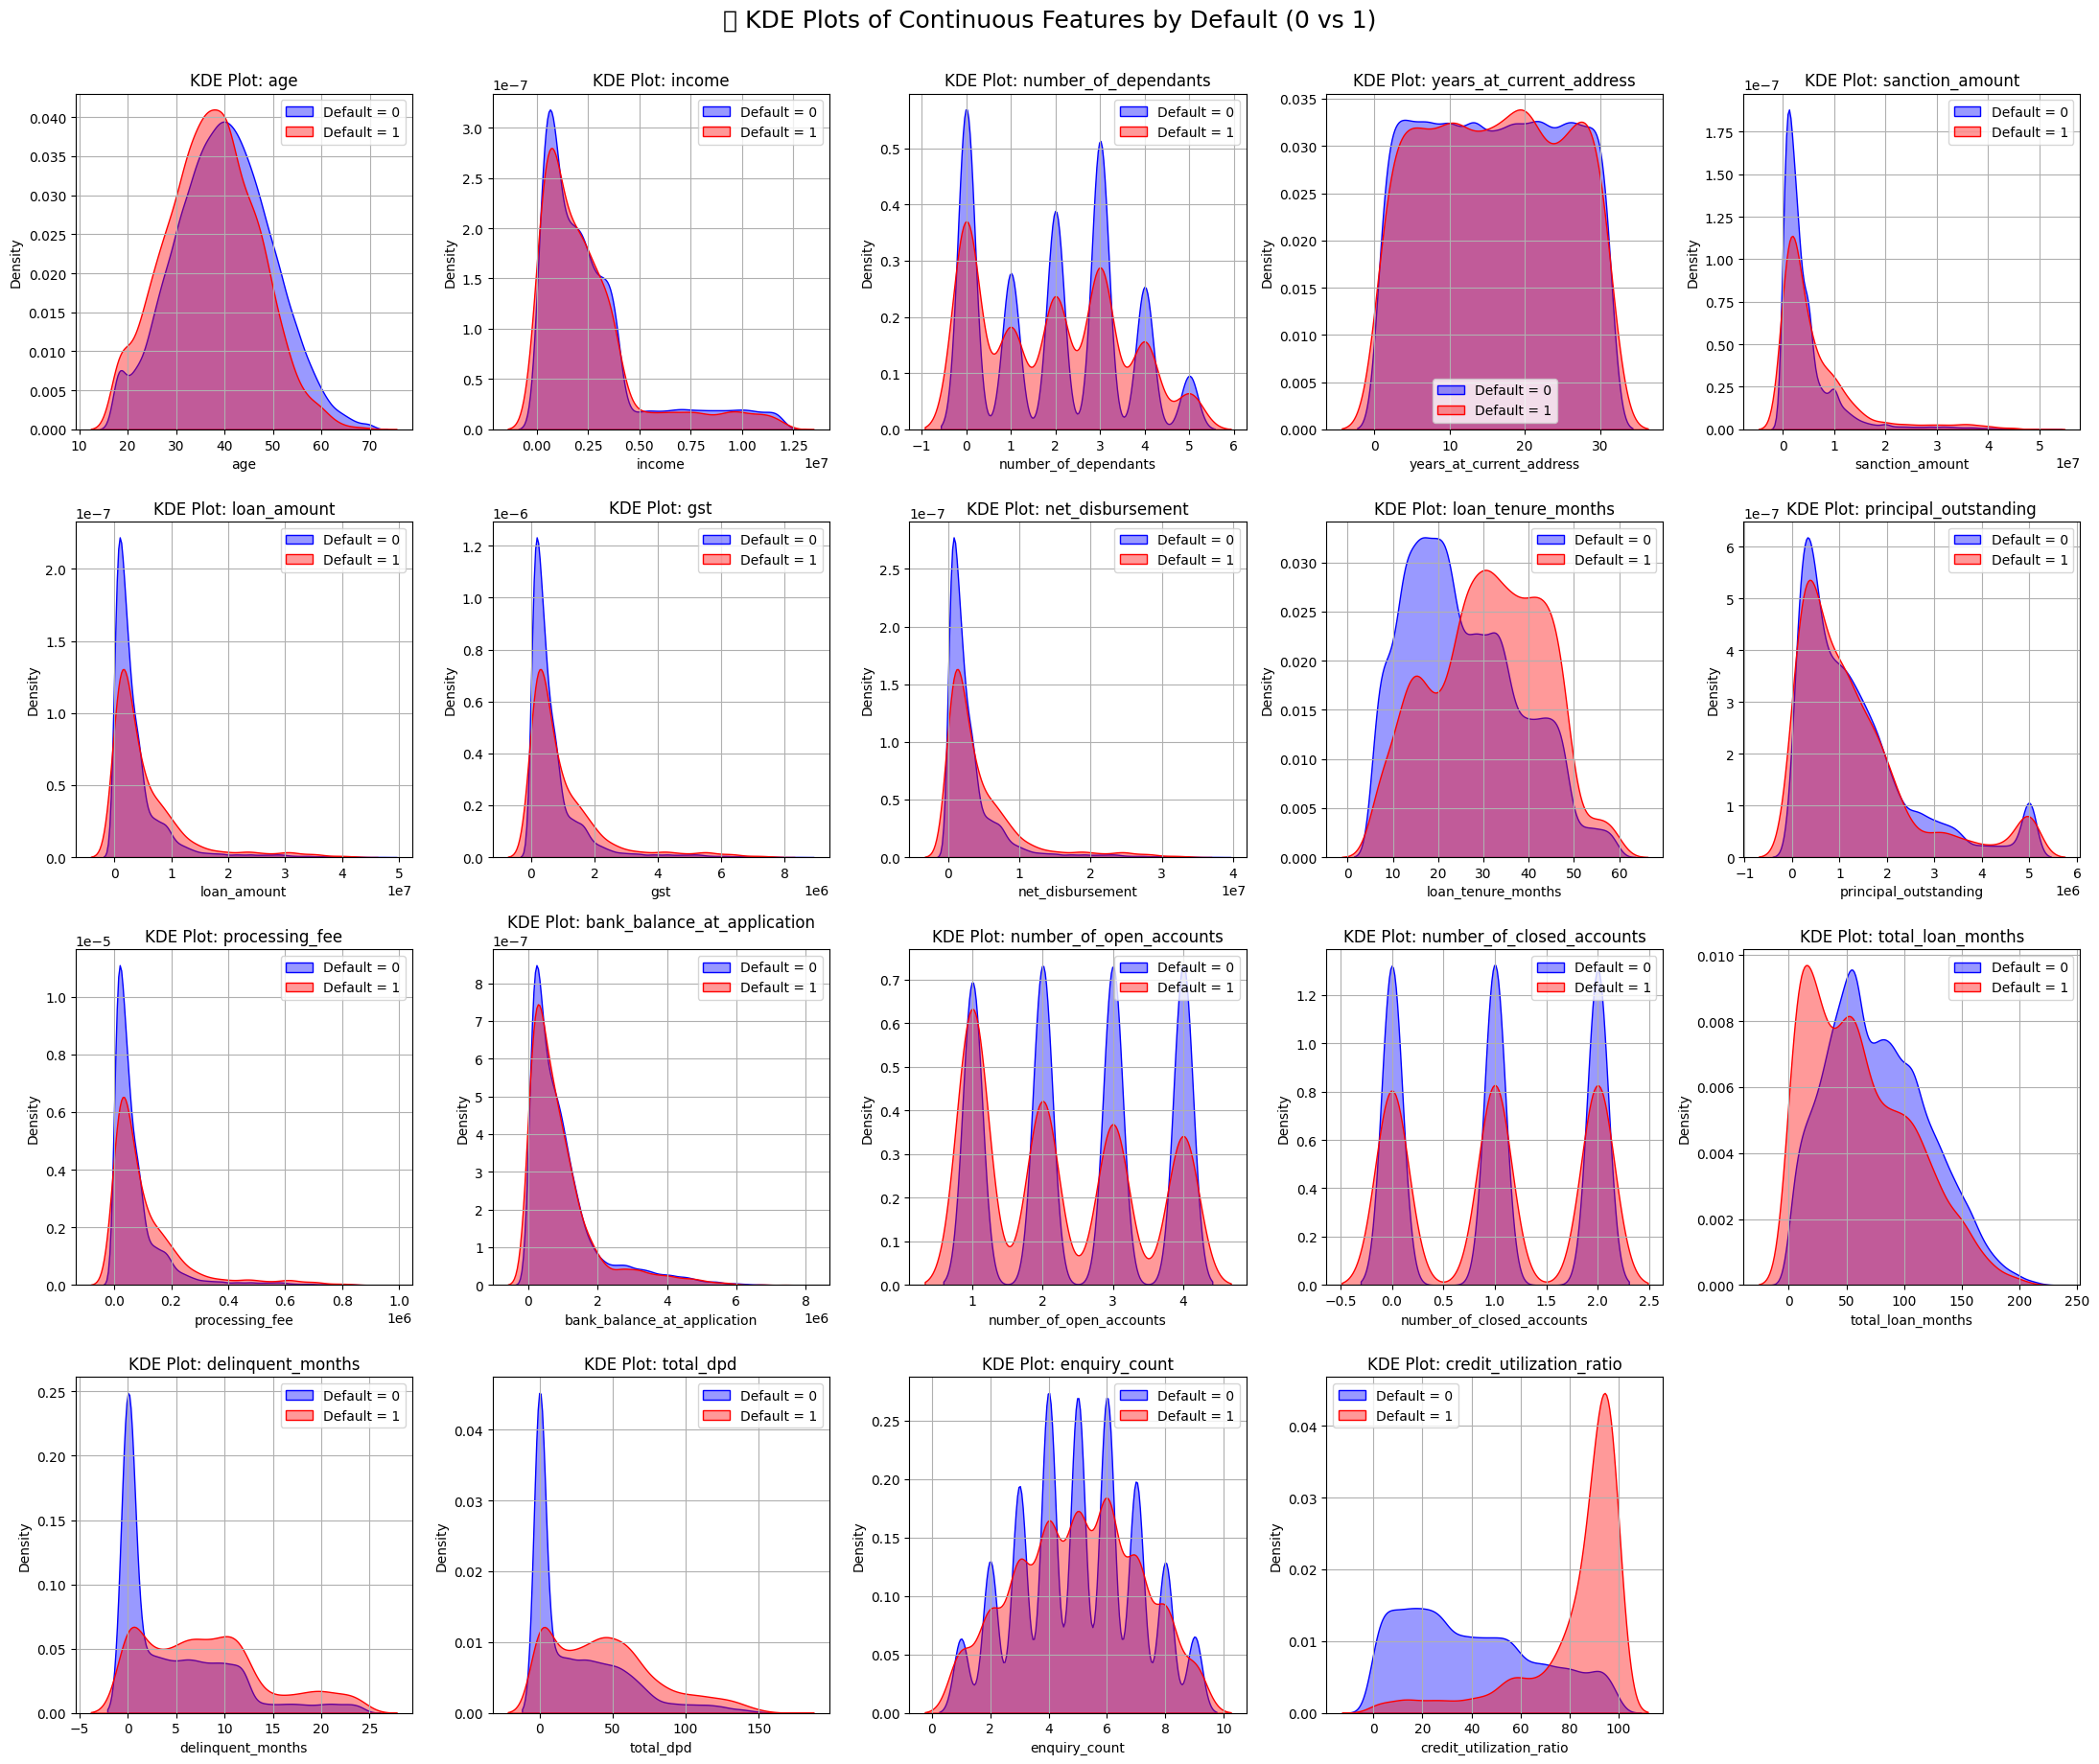

In [41]:
# Set up the grid
fig, axes = plt.subplots(4, 5, figsize=(22, 18))
axes = axes.flatten()

# Plot each KDE
for i, col in enumerate(continuous_col):
    ax = axes[i]
    sns.kdeplot(data=df_train1[df_train1['default'] == 0], x=col, ax=ax, label='Default = 0', fill=True, alpha=0.4, color='blue')
    sns.kdeplot(data=df_train1[df_train1['default'] == 1], x=col, ax=ax, label='Default = 1', fill=True, alpha=0.4, color='red')
    ax.set_title(f"KDE Plot: {col}", fontsize=12)
    ax.legend()
    ax.grid(True)

# Remove empty axes (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.suptitle("📈 KDE Plots of Continuous Features by Default (0 vs 1)", fontsize=18, y=1.02)
plt.show()

<h2 style="color:blue">KDE Analysis of Continuous Features vs Default</h2>

🔹 1. age
Defaulters tend to skew younger compared to non-defaulters.

There’s a visible peak in defaulters between 25–35 years.


🔹 2. income
Both distributions are highly right-skewed.

Slightly higher density of defaulters in the lower-income range.


🔹 3. number_of_dependants
Defaulters show higher densities in the 2–4 dependants range.

Multiple peaks indicate possible bucketed input or encoding.


🔹 4. years_at_current_address
Uniform distribution with slight differences.

Non-defaulters seem more evenly spread; defaulters peak in lower years.


🔹 5. sanction_amount / loan_amount / net_disbursement
Defaulters are more concentrated in lower sanctioned loan amounts.

As loan size increases, likelihood of default reduces (possibly better vetted borrowers).


🔹 6. gst / processing_fee / bank_balance_at_application
Strong right skew in all.

Defaulters tend to have slightly lower balances and pay smaller fees.


🔹 7. loan_tenure_months
Clear divergence: defaulters skew toward shorter tenures (12–36 months).

Longer tenure loans tend to default less, possibly due to better planning or vetting.


🔹 8. principal_outstanding
Defaulters typically have lower outstanding amounts, possibly due to early-stage defaults.


🔹 9. number_of_open_accounts / closed_accounts
Spiky distribution suggests categorical or rounded reporting.

Defaulters tend to have more open accounts.


🔹 10. total_loan_months / delinquent_months / total_dpd
Defaulters have longer total loan months and significantly more delinquent months and DPDs.

These are strong indicators of financial stress or poor repayment habits.


🔹 11. enquiry_count
Defaulters show more frequent credit enquiries.

Suggests higher credit-hungry behavior → riskier borrower profile.


🔹 12. credit_utilization_ratio
Very strong insight: defaulters have a high utilization ratio, clustered near 100%.

Non-defaulters show a wider, lower-spread.

One of the strongest predictors of default.



📌 Summary of Key Predictors:
High credit utilization

Frequent enquiries

Shorter loan tenures

Lower income and bank balance

Higher number of dependents

Longer delinquency & total DPD

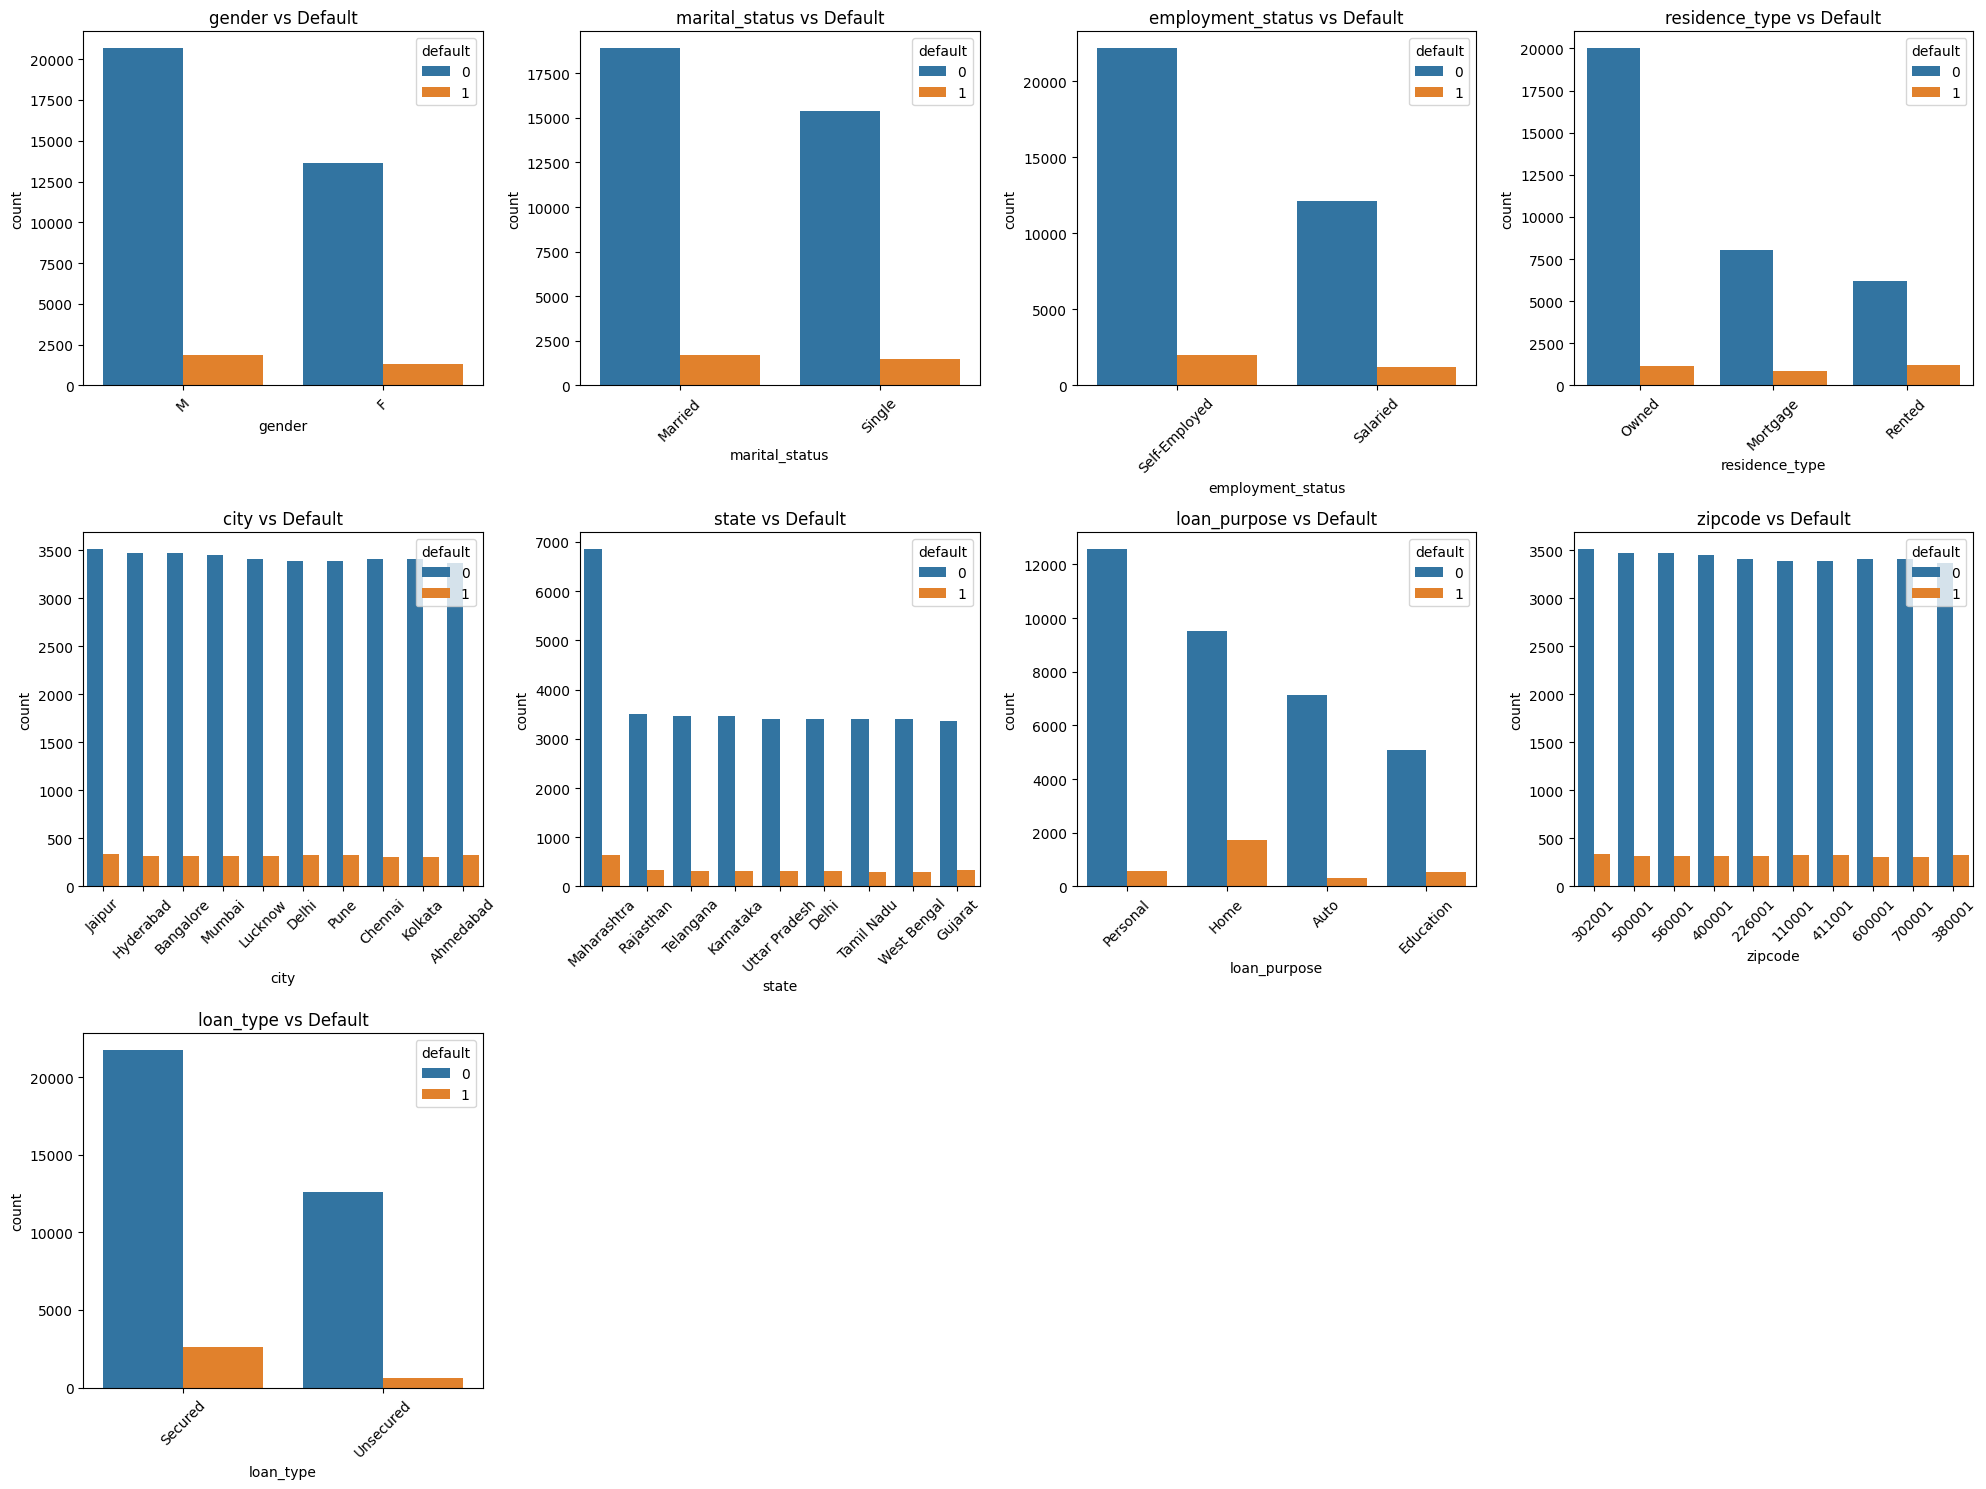

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_col = ['gender', 'marital_status', 'employment_status',
                   'residence_type', 'city', 'state', 'loan_purpose',
                   'zipcode', 'loan_type']

rows = 3
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_col):
    try:
        sns.countplot(data=df_train1, x=col, hue='default', ax=axes[i],
                      order=df_train1[col].value_counts().index)
        axes[i].set_title(f'{col} vs Default')
        axes[i].tick_params(axis='x', rotation=45)
    except Exception as e:
        print(f"Could not plot {col}: {e}")
        axes[i].axis('off')  # Hide broken plots

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<h3 style="color:blue">Categorical Variable Insights (vs Default)</h3>

✅ Key Categorical Insights (vs Default)

1 secured loans have a significantly higher default rate than unsecured loans.

2 Self-employed individuals are more likely to default than salaried ones.

3 Personal loans show the highest default rate among all loan purposes.

4 Rented and mortgaged homes are associated with higher default compared to owned residences.



<h2 align="center" style="color:blue">Feature Engineering</h2>


In [43]:
df_train1 ['loan_to_income'] = df_train1 ['loan_amount']/df_train1['income']
df_train1.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default,loan_to_income
count,"37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00",...,"37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00"
mean,39.56,"2,636,119.11",1.94,15.99,"418,763.45","4,707,707.29","4,003,661.08","80,073.22","720,658.99","3,202,928.87",...,"987,509.19",2.50,1.00,75.99,4.89,26.94,5.00,43.33,0.09,1.55
std,9.85,"2,623,816.51",1.54,8.94,"168,837.51","6,289,437.60","5,401,552.03","108,031.04","972,279.36","4,321,241.62",...,"1,044,992.95",1.12,0.82,43.71,5.86,32.93,2.02,29.36,0.28,0.97
min,18.00,"100,000.00",0.00,1.00,"110,001.00","71,000.00","50,000.00","1,000.00","9,000.00","40,000.00",...,"19,415.00",1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.30
25%,33.00,"803,000.00",0.00,8.00,"302,001.00","1,136,000.00","959,500.00","19,190.00","172,710.00","767,600.00",...,"286,231.50",1.00,0.00,42.00,0.00,0.00,4.00,18.00,0.00,0.77
50%,40.00,"1,884,000.00",2.00,16.00,"400,001.00","2,652,000.00","2,235,000.00","44,700.00","402,300.00","1,788,000.00",...,"666,885.00",2.00,1.00,71.00,3.00,14.00,5.00,39.00,0.00,1.16
75%,46.00,"3,331,500.00",3.00,24.00,"560,001.00","5,159,500.00","4,598,000.00","91,960.00","827,640.00","3,678,400.00",...,"1,236,742.00",3.00,2.00,107.00,9.00,46.00,6.00,67.00,0.00,2.45
max,70.00,"11,999,000.00",5.00,31.00,"700,001.00","52,175,000.00","47,667,000.00","953,340.00","8,580,060.00","38,133,600.00",...,"7,846,643.00",4.00,2.00,223.00,24.00,171.00,9.00,99.00,1.00,4.57


In [44]:
df_test ['loan_to_income'] = df_test ['loan_amount']/df_test['income']
df_test.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,...,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default,loan_to_income
count,"12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00",...,"12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00","12,498.00"
mean,39.51,"2,655,850.46",1.93,16.09,"420,098.06","4,699,942.39","3,990,963.83","79,819.28","718,373.49","3,192,771.07",...,"994,262.29",2.51,1.01,76.51,4.84,26.61,5.03,43.46,0.09,1.56
std,9.83,"2,645,328.29",1.53,8.89,"169,419.47","6,203,040.94","5,303,217.21","106,064.34","954,579.10","4,242,573.77",...,"1,048,991.19",1.12,0.81,43.93,5.81,32.54,2.04,29.36,0.28,0.97
min,18.00,"100,000.00",0.00,1.00,"110,001.00","72,000.00","56,000.00","1,120.00","10,080.00","44,800.00",...,"21,106.00",1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.30
25%,33.00,"805,000.00",0.00,8.00,"302,001.00","1,176,000.00","989,250.00","19,785.00","178,065.00","791,400.00",...,"289,595.75",1.00,0.00,43.00,0.00,0.00,4.00,18.00,0.00,0.77
50%,40.00,"1,916,500.00",2.00,16.00,"411,001.00","2,669,500.00","2,252,000.00","45,040.00","405,360.00","1,801,600.00",...,"673,572.00",3.00,1.00,72.00,3.00,14.00,5.00,39.00,0.00,1.17
75%,46.00,"3,336,750.00",3.00,24.00,"560,001.00","5,236,500.00","4,654,250.00","93,085.00","837,765.00","3,723,400.00",...,"1,245,243.00",4.00,2.00,107.00,8.00,46.00,7.00,67.00,0.00,2.45
max,70.00,"11,990,000.00",5.00,31.00,"700,001.00","49,622,000.00","47,819,000.00","956,380.00","8,607,420.00","38,255,200.00",...,"6,903,073.00",4.00,2.00,221.00,24.00,162.00,9.00,99.00,1.00,4.59


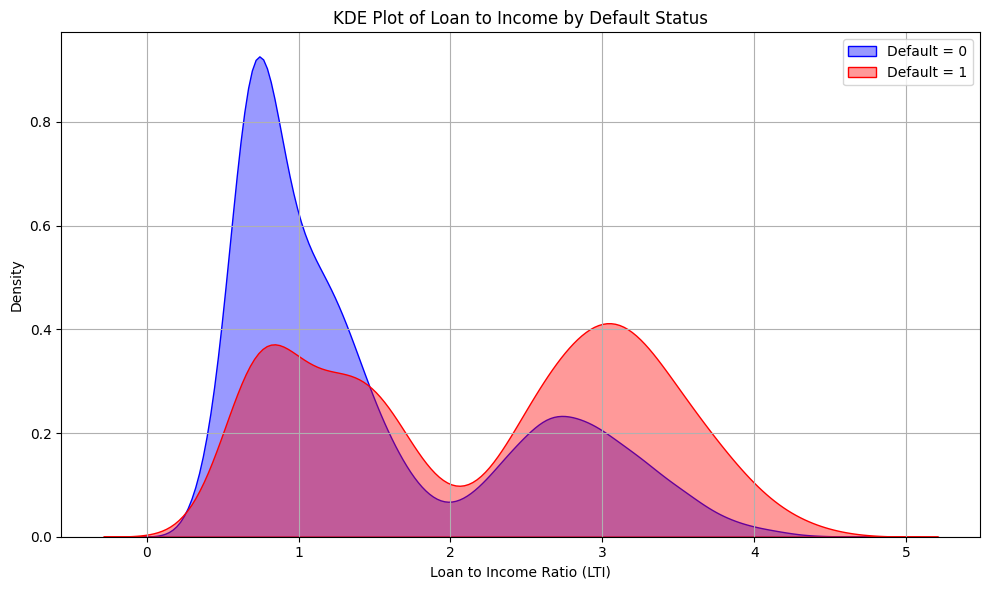

In [45]:

plt.figure(figsize=(10, 6))

# KDE plot for default = 0
sns.kdeplot(data=df_train1[df_train1['default'] == 0], 
            x='loan_to_income', 
            label='Default = 0', 
            fill=True, 
            alpha=0.4, 
            color='blue')

# KDE plot for default = 1
sns.kdeplot(data=df_train1[df_train1['default'] == 1], 
            x='loan_to_income', 
            label='Default = 1', 
            fill=True, 
            alpha=0.4, 
            color='red')

plt.title('KDE Plot of Loan to Income by Default Status')
plt.xlabel('Loan to Income Ratio (LTI)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [46]:
df_train1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income'],
      dtype='object')

In [47]:
df_train1['delinquency_ratio'] = np.where(
    df_train1['delinquent_months']!= 0,
    (df_train1['delinquent_months']*100/df_train1['total_loan_months']),0)
df_train1[['delinquent_months','total_loan_months','delinquency_ratio']].head(3)

,delinquent_months,total_loan_months,delinquency_ratio
27434,6,90,6.67
13400,4,119,3.36
883,14,83,16.87


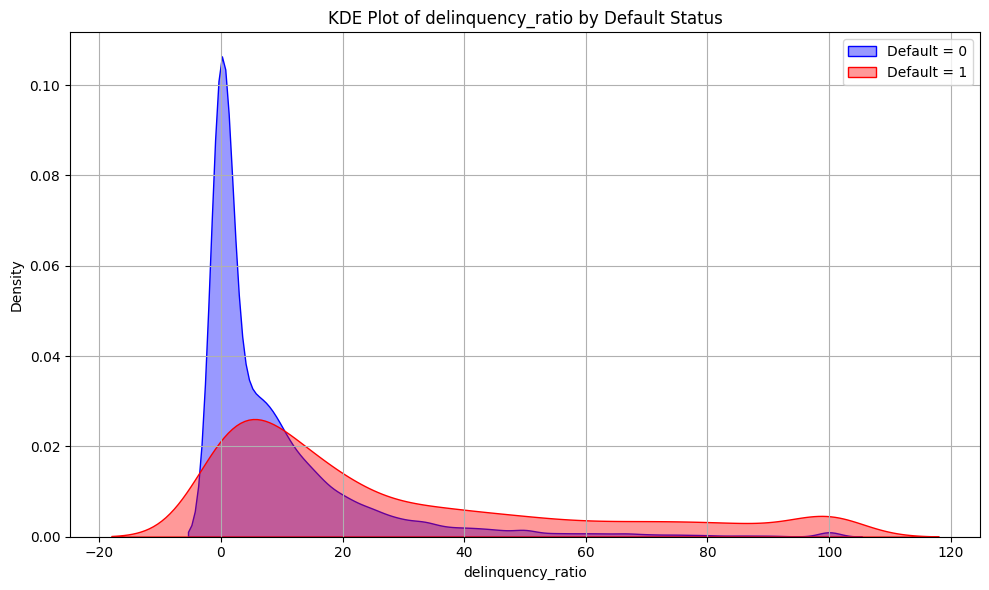

In [48]:

plt.figure(figsize=(10, 6))

# KDE plot for default = 0
sns.kdeplot(data=df_train1[df_train1['default'] == 0], 
            x='delinquency_ratio', 
            label='Default = 0', 
            fill=True, 
            alpha=0.4, 
            color='blue')

# KDE plot for default = 1
sns.kdeplot(data=df_train1[df_train1['default'] == 1], 
            x='delinquency_ratio', 
            label='Default = 1', 
            fill=True, 
            alpha=0.4, 
            color='red')

plt.title('KDE Plot of delinquency_ratio by Default Status')
plt.xlabel('delinquency_ratio')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
df_test['delinquency_ratio'] = np.where(
    df_test['delinquent_months']!= 0,
    (df_test['delinquent_months']*100/df_test['total_loan_months']),0)
df_test['delinquency_ratio'].isnull().sum()

0

In [50]:
df_train1['avg_dpd_per_delinquency']=np.where(
    df_train1['delinquent_months']!= 0,
    (df_train1['total_dpd']/df_train1['delinquent_months']),0)
df_train1['avg_dpd_per_delinquency'].isnull().sum()

0

In [51]:
df_test['avg_dpd_per_delinquency']=np.where(
    df_test['delinquent_months']!= 0,
    (df_test['total_dpd']/df_test['delinquent_months']),0)
df_test['avg_dpd_per_delinquency'].isnull().sum()

0

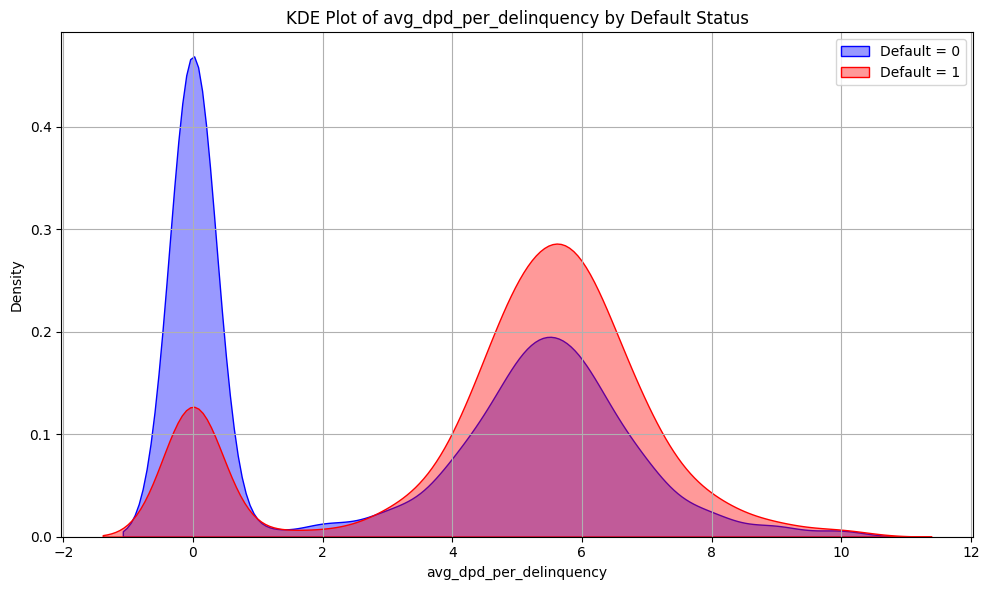

In [52]:

plt.figure(figsize=(10, 6))

# KDE plot for default = 0
sns.kdeplot(data=df_train1[df_train1['default'] == 0], 
            x='avg_dpd_per_delinquency', 
            label='Default = 0', 
            fill=True, 
            alpha=0.4, 
            color='blue')

# KDE plot for default = 1
sns.kdeplot(data=df_train1[df_train1['default'] == 1], 
            x='avg_dpd_per_delinquency', 
            label='Default = 1', 
            fill=True, 
            alpha=0.4, 
            color='red')

plt.title('KDE Plot of avg_dpd_per_delinquency by Default Status')
plt.xlabel('avg_dpd_per_delinquency')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [53]:
df_train1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [54]:
df_test.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [55]:
df_train1['util_enquiry_interaction'] = df_train1['credit_utilization_ratio'] * df_train1['enquiry_count']

In [56]:
df_test['util_enquiry_interaction'] = df_test['credit_utilization_ratio'] * df_test['enquiry_count']

In [57]:
df_train1['loan_to_balance'] = df_train1['loan_amount'] / (df_train1['bank_balance_at_application'] + 1)

In [58]:
df_test['loan_to_balance'] = df_test['loan_amount'] / (df_test['bank_balance_at_application'] + 1)

In [59]:
df_train1['account_stability'] = df_train1['number_of_closed_accounts'] / (df_train1['number_of_open_accounts'] + 1)

In [60]:
df_test['account_stability'] = df_test['number_of_closed_accounts'] / (df_test['number_of_open_accounts'] + 1)

### Feature selection

In [61]:
df_train2= df_train1.drop(['cust_id','loan_id','sanction_amount','income','loan_amount','total_loan_months', 'delinquent_months',
       'total_dpd','disbursal_date'], axis=1)
df_test = df_test.drop(['cust_id','loan_id','sanction_amount','income','loan_amount','total_loan_months', 'delinquent_months',
       'total_dpd','disbursal_date'], axis=1)

In [62]:
df_train2.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency',
       'util_enquiry_interaction', 'loan_to_balance', 'account_stability'],
      dtype='object')

In [63]:
df_train2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37487 entries, 27434 to 15795
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37487 non-null  int64  
 1   gender                       37487 non-null  object 
 2   marital_status               37487 non-null  object 
 3   employment_status            37487 non-null  object 
 4   number_of_dependants         37487 non-null  int64  
 5   residence_type               37487 non-null  object 
 6   years_at_current_address     37487 non-null  int64  
 7   city                         37487 non-null  object 
 8   state                        37487 non-null  object 
 9   zipcode                      37487 non-null  int64  
 10  loan_purpose                 37487 non-null  object 
 11  loan_type                    37487 non-null  object 
 12  processing_fee               37487 non-null  float64
 13  gst              

In [64]:
continuous_col = [
    'age',
    'number_of_dependants',
    'years_at_current_address',
    'processing_fee',
    'gst',
    'net_disbursement',
    'loan_tenure_months',
    'principal_outstanding',
    'bank_balance_at_application',
    'number_of_open_accounts',
    'number_of_closed_accounts',
    'enquiry_count',
    'credit_utilization_ratio',
    'loan_to_income',
    'delinquency_ratio',
    'avg_dpd_per_delinquency',
    'util_enquiry_interaction',
    'account_stability',
    'loan_to_balance'
    
]

In [65]:
categorical_col = [
    'gender',
    'marital_status',
    'employment_status',
    'residence_type',
    'city',
    'state',
    'zipcode',        
    'loan_purpose',
    'loan_type'
]

In [66]:
target_col = 'default'

In [67]:
categorical_cols = categorical_col.copy()
continuous_cols = continuous_col.copy()

In [68]:
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

if target_col in continuous_cols:
    continuous_cols.remove(target_col)

In [69]:
print(target_col in categorical_cols)
print(target_col in continuous_cols)

False
False


In [70]:
print(df_train2.columns.tolist())

['age', 'gender', 'marital_status', 'employment_status', 'number_of_dependants', 'residence_type', 'years_at_current_address', 'city', 'state', 'zipcode', 'loan_purpose', 'loan_type', 'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 'bank_balance_at_application', 'installment_start_dt', 'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count', 'credit_utilization_ratio', 'default', 'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency', 'util_enquiry_interaction', 'loan_to_balance', 'account_stability']


In [71]:
print(continuous_cols)

['age', 'number_of_dependants', 'years_at_current_address', 'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 'bank_balance_at_application', 'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count', 'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency', 'util_enquiry_interaction', 'account_stability', 'loan_to_balance']


In [72]:
continuous_cols = [col for col in continuous_cols if col in df_train2.columns]
categorical_cols = [col for col in categorical_cols if col in df_train2.columns]

In [73]:
import numpy as np
import pandas as pd

# -------------------------------
# Step 1: Define features
# -------------------------------
continuous_cols = [
    'credit_utilization_ratio',
    'delinquency_ratio',
    'loan_to_income',
    'loan_tenure_months',
    'net_disbursement',
    'age',
    'number_of_open_accounts',

    # NEW FEATURES
    'util_enquiry_interaction',
    'loan_to_balance',
    'account_stability'
]

target_col = 'default'

# -------------------------------
# Step 2: Initialize storage
# -------------------------------
woe_cont_dict = {}
bin_edges_dict = {}
iv_cont_list = []

# -------------------------------
# Step 3: Loop through features
# -------------------------------
for col in continuous_cols:

    print(f"\n===== {col} =====")

    try:
        df_train2['_bin'], bin_edges = pd.qcut(
            df_train2[col], q=5, duplicates='drop', retbins=True
        )
    except Exception as e:
        print(f"Skipping {col} due to error: {e}")
        continue

    # Grouping
    grouped = df_train2.groupby('_bin', observed=False)[target_col].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'sum': 'event'})

    grouped['non_event'] = grouped['count'] - grouped['event']

    # Handle zero
    grouped['event'] = grouped['event'].replace(0, 0.5)
    grouped['non_event'] = grouped['non_event'].replace(0, 0.5)

    # Distribution
    grouped['dist_event'] = grouped['event'] / grouped['event'].sum()
    grouped['dist_non_event'] = grouped['non_event'] / grouped['non_event'].sum()

    # WoE
    grouped['woe'] = np.log(grouped['dist_event'] / grouped['dist_non_event'])

    # IV
    grouped['iv'] = (grouped['dist_event'] - grouped['dist_non_event']) * grouped['woe']
    iv_value = grouped['iv'].sum()

    # Store
    iv_cont_list.append({'feature': col, 'IV': iv_value})
    woe_map = grouped['woe'].to_dict()
    woe_cont_dict[col] = woe_map
    bin_edges_dict[col] = bin_edges

    # Apply WoE to TRAIN
    df_train2[col + '_woe'] = df_train2['_bin'].map(woe_map).astype(float)

    # Apply WoE to TEST (FIXED PART)
    df_test['_bin'] = pd.cut(df_test[col], bins=bin_edges, include_lowest=True)

    df_test[col + '_woe'] = (
        df_test['_bin']
        .map(woe_map)
        .astype(float)     # ✅ convert BEFORE fillna
        .fillna(0)
    )

    # Print
    grouped['event_rate'] = grouped['event'] / grouped['count']
    print(grouped[['count', 'event', 'non_event', 'event_rate', 'woe', 'iv']])
    print(f"IV = {iv_value:.4f}")

    # Cleanup
    df_train2.drop(columns=['_bin'], inplace=True)
    df_test.drop(columns=['_bin'], inplace=True)

# -------------------------------
# Step 4: IV summary
# -------------------------------
iv_cont_df = pd.DataFrame(iv_cont_list).sort_values(by='IV', ascending=False)
iv_cont_df['IV'] = iv_cont_df['IV'].round(3)

print("\n===== FINAL IV SUMMARY =====")
print(iv_cont_df)


===== credit_utilization_ratio =====
                count  event  non_event  event_rate   woe   iv
_bin                                                          
(-0.001, 14.0]   7597     84       7513        0.01 -2.12 0.41
(14.0, 29.0]     7546     88       7458        0.01 -2.06 0.39
(29.0, 49.0]     7406    120       7286        0.02 -1.73 0.30
(49.0, 74.0]     7462    399       7063        0.05 -0.50 0.04
(74.0, 99.0]     7476   2498       4978        0.33  1.69 1.08
IV = 2.2188

===== delinquency_ratio =====
                 count  event  non_event  event_rate   woe   iv
_bin                                                           
(-0.001, 6.977]  22506    984      21522        0.04 -0.71 0.23
(6.977, 16.299]   7483    671       6812        0.09  0.06 0.00
(16.299, 100.0]   7498   1534       5964        0.20  1.02 0.31
IV = 0.5396

===== loan_to_income =====
                count  event  non_event  event_rate   woe   iv
_bin                                                   

In [76]:
woe_cat_dict = {}
iv_cat_list = {}
woe_cat_table = {}

for col in categorical_cols:
    
    print(f"\n===== {col} =====")
    
    # Step 1: Group
    grouped = df_train2.groupby(col)[target_col].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'sum': 'event'})
    
    grouped['non_event'] = grouped['count'] - grouped['event']
    
    # Step 2: Handle zero
    grouped['event'] = grouped['event'].replace(0, 0.5)
    grouped['non_event'] = grouped['non_event'].replace(0, 0.5)
    
    # Step 3: Distribution
    grouped['dist_event'] = grouped['event'] / grouped['event'].sum()
    grouped['dist_non_event'] = grouped['non_event'] / grouped['non_event'].sum()
    
    # Step 4: WoE
    grouped['woe'] = np.log(grouped['dist_event'] / grouped['dist_non_event'])
    
    # Step 5: IV
    grouped['iv'] = (grouped['dist_event'] - grouped['dist_non_event']) * grouped['woe']
    iv_value = grouped['iv'].sum()
    
    # Step 6: Event rate (VERY IMPORTANT)
    grouped['event_rate'] = grouped['event'] / grouped['count']
    
    # Store IV
    iv_cat_list[col] = iv_value
    
    # Store WoE mapping
    woe_cat_dict[col] = grouped['woe'].to_dict()
    
    # Store full table (for analysis)
    woe_cat_table[col] = grouped
    
    # Print
    print(grouped[['count', 'event', 'non_event', 'event_rate', 'woe', 'iv']])
    print(f"IV = {iv_value:.4f}")


===== gender =====
        count  event  non_event  event_rate   woe   iv
gender                                                
F       14924   1301      13623        0.09  0.03 0.00
M       22563   1888      20675        0.08 -0.02 0.00
IV = 0.0005

===== marital_status =====
                count  event  non_event  event_rate   woe   iv
marital_status                                                
Married         20585   1683      18902        0.08 -0.04 0.00
Single          16902   1506      15396        0.09  0.05 0.00
IV = 0.0022

===== employment_status =====
                   count  event  non_event  event_rate   woe   iv
employment_status                                                
Salaried           13336   1204      12132        0.09  0.07 0.00
Self-Employed      24151   1985      22166        0.08 -0.04 0.00
IV = 0.0024

===== residence_type =====
                count  event  non_event  event_rate   woe   iv
residence_type                                            

In [77]:
for col in categorical_cols:
    df_train2[col + '_woe'] = df_train2[col].map(woe_cat_dict[col]).astype(float)

In [78]:
iv_cat_df = pd.DataFrame(
    [{'feature': k, 'IV': v} for k, v in iv_cat_list.items()]
).sort_values(by='IV', ascending=False)

iv_cat_df['IV'] = iv_cat_df['IV'].round(3)

print(iv_cat_df)

             feature   IV
7       loan_purpose 0.39
3     residence_type 0.26
8          loan_type 0.17
2  employment_status 0.00
1     marital_status 0.00
4               city 0.00
6            zipcode 0.00
5              state 0.00
0             gender 0.00


In [79]:
for col in categorical_cols:
    df_test[col + '_woe'] = df_test[col].map(woe_cat_dict[col]).fillna(0).astype(float)

In [80]:
iv_total_df = pd.concat([iv_cont_df, iv_cat_df])
iv_total_df.sort_values(by='IV', ascending=False)

,feature,IV
0,credit_utilization_ratio,2.22
7,util_enquiry_interaction,1.10
1,delinquency_ratio,0.54
2,loan_to_income,0.46
7,loan_purpose,0.39
8,loan_to_balance,0.38
3,residence_type,0.26
3,loan_tenure_months,0.22
8,loan_type,0.17
4,net_disbursement,0.10


In [81]:
iv_selected_features = iv_total_df[iv_total_df['IV'] >= 0.02]['feature'].tolist()

In [82]:
iv_selected_features

['credit_utilization_ratio',
 'util_enquiry_interaction',
 'delinquency_ratio',
 'loan_to_income',
 'loan_to_balance',
 'loan_tenure_months',
 'net_disbursement',
 'age',
 'number_of_open_accounts',
 'account_stability',
 'loan_purpose',
 'residence_type',
 'loan_type']

In [83]:
iv_selected_features = [
 'credit_utilization_ratio',
 'util_enquiry_interaction',
 'delinquency_ratio',
 'loan_to_income',
 'loan_to_balance',
 'loan_tenure_months',
 'net_disbursement',
 'age',
 'number_of_open_accounts',
 'account_stability',
 'loan_purpose',
 'residence_type',
 'loan_type'
    
]

woe_features = [col + '_woe' for col in iv_selected_features]

In [84]:
print(df_train2.columns)

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency',
       'util_enquiry_interaction', 'loan_to_balance', 'account_stability',
       'credit_utilization_ratio_woe', 'delinquency_ratio_woe',
       'loan_to_income_woe', 'loan_tenure_months_woe', 'net_disbursement_woe',
       'age_woe', 'number_of_open_accounts_woe',
       'util_enquiry_interaction_woe', 'loan_to_balance_woe',
       'account_stability_woe', 'gender_woe', 'marital_status_woe',
       'employment_status_woe', 

In [85]:
X_vif = df_train2[woe_features].copy()

In [86]:
X_vif = X_vif.apply(pd.to_numeric, errors='coerce')
X_vif = X_vif.fillna(0)

In [87]:
import statsmodels.api as sm
X_vif = sm.add_constant(X_vif)

In [88]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(X_vif.shape[1])]

# Remove constant
vif_data = vif_data[vif_data['feature'] != 'const']

# Sort
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

                         feature  VIF
4             loan_to_income_woe 8.25
11              loan_purpose_woe 7.46
5            loan_to_balance_woe 5.44
6         loan_tenure_months_woe 2.64
13                 loan_type_woe 2.40
2   util_enquiry_interaction_woe 2.39
1   credit_utilization_ratio_woe 2.28
7           net_disbursement_woe 1.37
9    number_of_open_accounts_woe 1.32
8                        age_woe 1.23
10         account_stability_woe 1.17
3          delinquency_ratio_woe 1.08
12            residence_type_woe 1.01


In [89]:
final_features = [
 'credit_utilization_ratio',
 'delinquency_ratio',
 'loan_to_income',
 'loan_tenure_months',
 'net_disbursement',
 'age',
 'number_of_open_accounts',
 'loan_purpose',
 'residence_type',
 'loan_type',
 'util_enquiry_interaction',
 'account_stability',
 'loan_to_balance'
]

final_woe_features = [col + '_woe' for col in final_features]

In [90]:
X_train_model = df_train2[final_woe_features].copy()
y_train_model = df_train2[target_col].copy()

In [91]:
X_test_model = df_test[final_woe_features].copy()
y_test_model = y_test.copy()

In [92]:
print(X_train_model.shape, y_train_model.shape)
print(X_test_model.shape, y_test_model.shape)

(37487, 13) (37487,)
(12498, 13) (12500,)


In [93]:
y_test_model = y_test.loc[X_test_model.index]

In [94]:
print(X_test_model.shape)
print(y_test_model.shape)

(12498, 13)
(12498,)


In [95]:
X_train_model = X_train_model.apply(pd.to_numeric, errors='coerce')

In [96]:
X_train_model = X_train_model.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_model  = X_test_model.apply(pd.to_numeric, errors='coerce').fillna(0)

In [97]:
print(X_train_model.dtypes)

credit_utilization_ratio_woe    float64
delinquency_ratio_woe           float64
loan_to_income_woe              float64
loan_tenure_months_woe          float64
net_disbursement_woe            float64
age_woe                         float64
number_of_open_accounts_woe     float64
loan_purpose_woe                float64
residence_type_woe              float64
loan_type_woe                   float64
util_enquiry_interaction_woe    float64
account_stability_woe           float64
loan_to_balance_woe             float64
dtype: object


In [98]:
print(X_train_model.isnull().sum())
print(X_test_model.isnull().sum())

credit_utilization_ratio_woe    0
delinquency_ratio_woe           0
loan_to_income_woe              0
loan_tenure_months_woe          0
net_disbursement_woe            0
age_woe                         0
number_of_open_accounts_woe     0
loan_purpose_woe                0
residence_type_woe              0
loan_type_woe                   0
util_enquiry_interaction_woe    0
account_stability_woe           0
loan_to_balance_woe             0
dtype: int64
credit_utilization_ratio_woe    0
delinquency_ratio_woe           0
loan_to_income_woe              0
loan_tenure_months_woe          0
net_disbursement_woe            0
age_woe                         0
number_of_open_accounts_woe     0
loan_purpose_woe                0
residence_type_woe              0
loan_type_woe                   0
util_enquiry_interaction_woe    0
account_stability_woe           0
loan_to_balance_woe             0
dtype: int64


In [99]:
X_train_model.describe()

,credit_utilization_ratio_woe,delinquency_ratio_woe,loan_to_income_woe,loan_tenure_months_woe,net_disbursement_woe,age_woe,number_of_open_accounts_woe,loan_purpose_woe,residence_type_woe,loan_type_woe,util_enquiry_interaction_woe,account_stability_woe,loan_to_balance_woe
count,"37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00","37,487.00"
mean,-0.95,-0.21,-0.19,-0.09,-0.04,-0.03,-0.02,-0.17,-0.10,-0.08,-0.47,-0.01,-0.16
std,1.44,0.68,0.66,0.48,0.29,0.26,0.21,0.63,0.48,0.45,1.06,0.14,0.62
min,-2.12,-0.71,-0.89,-0.61,-0.24,-0.50,-0.27,-0.75,-0.49,-0.69,-1.82,-0.16,-0.87
25%,-2.06,-0.71,-0.67,-0.61,-0.21,-0.15,-0.19,-0.69,-0.49,-0.69,-1.07,-0.08,-0.65
50%,-1.73,-0.71,-0.50,-0.05,-0.21,0.02,0.19,-0.69,-0.49,0.25,-0.68,-0.08,-0.36
75%,-0.50,0.06,0.20,0.33,-0.06,0.15,0.19,0.68,0.11,0.25,-0.01,0.18,0.31
max,1.69,1.02,0.91,0.56,0.53,0.27,0.19,0.68,0.74,0.25,1.28,0.20,0.78


<h2 align="center" style="color:blue"> Model Training </h2>


### Attemp 1) 

#### Model = LogisticRegression , XGBClassifier , RandomForestClassifier , RandomizedSearchCV

#### without Handling class imbalance 

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_model,y_train_model)

y_pred = model.predict(X_test_model)
report = classification_report(y_test_model,y_pred) 
print(report)

              precision    recall  f1-score   support

           0       0.95      0.98      0.97     11390
           1       0.74      0.50      0.59      1108

    accuracy                           0.94     12498
   macro avg       0.85      0.74      0.78     12498
weighted avg       0.93      0.94      0.93     12498



In [101]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_model,y_train_model)

y_pred = model.predict(X_test_model)
report = classification_report(y_test_model,y_pred) 
print(report)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96     11390
           1       0.67      0.49      0.57      1108

    accuracy                           0.93     12498
   macro avg       0.81      0.74      0.77     12498
weighted avg       0.93      0.93      0.93     12498



In [102]:
from xgboost import XGBClassifier 

model = XGBClassifier()
model.fit(X_train_model,y_train_model)

y_pred = model.predict(X_test_model)
report = classification_report(y_test_model,y_pred) 
print(report)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11390
           1       0.69      0.54      0.61      1108

    accuracy                           0.94     12498
   macro avg       0.82      0.76      0.79     12498
weighted avg       0.93      0.94      0.93     12498



In [103]:
# Step 3: Define logistic regression and param grid
log_reg = LogisticRegression(solver='saga', max_iter=10000, random_state=42)

param_dist = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]  # Only used for elasticnet
}

# Step 4: Run RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_model, y_train_model)

# Step 5: Show best results
print("\nBest Parameters:")
print(random_search.best_params_)
print(f"Best ROC-AUC Score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'penalty': 'l2', 'l1_ratio': 0.1, 'C': 1}
Best ROC-AUC Score: 0.9588


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [104]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Step 1: Predict on validation set
y_pred = random_search.predict(X_test_model)
y_proba = random_search.predict_proba(X_test_model)[:, 1]  # for ROC-AUC

# Step 2: Confusion matrix
cm = confusion_matrix(y_test_model, y_pred)
print("Confusion Matrix:\n", cm)

# Step 3: Classification report
print("\nClassification Report:")
print(classification_report(y_test_model, y_pred))

# Step 4: ROC-AUC Score
roc_auc = roc_auc_score(y_test_model, y_proba)
print(f"Validation ROC-AUC Score: {roc_auc:.4f}")


Confusion Matrix:
 [[11193   197]
 [  557   551]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     11390
           1       0.74      0.50      0.59      1108

    accuracy                           0.94     12498
   macro avg       0.84      0.74      0.78     12498
weighted avg       0.93      0.94      0.93     12498

Validation ROC-AUC Score: 0.9556


In [105]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0.5, 1, 2]
}



random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train_model, y_train_model)

# Show best parameters
print("\nBest Parameters (XGBoost):")
print(random_search_xgb.best_params_)
print(f"Best ROC-AUC Score: {random_search_xgb.best_score_:.4f}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters (XGBoost):
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}
Best ROC-AUC Score: 0.9634


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:39:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [106]:
# Predict on validation set
y_pred = random_search_xgb.predict(X_test_model)
y_proba = random_search_xgb.predict_proba(X_test_model)[:, 1]

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_model, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_model, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"Validation ROC-AUC Score: {roc_auc:.4f}")



Confusion Matrix:
[[11176   214]
 [  524   584]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11390
           1       0.73      0.53      0.61      1108

    accuracy                           0.94     12498
   macro avg       0.84      0.75      0.79     12498
weighted avg       0.94      0.94      0.94     12498



ValueError: Found input variables with inconsistent numbers of samples: [12500, 12498]

### Attemp 2) 

#### Model = LogisticRegression , XGBClassifier

#### Handling class imbalance using under sampling


In [107]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_rus ,y_train_rus =  rus.fit_resample(X_train_model,y_train_model)
y_train_rus.value_counts()

default
0    3189
1    3189
Name: count, dtype: int64

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_rus,y_train_rus)

y_pred = model.predict(X_test_model)
report = classification_report(y_test_model,y_pred) 
print(report)

              precision    recall  f1-score   support

           0       0.99      0.89      0.93     11390
           1       0.43      0.90      0.59      1108

    accuracy                           0.89     12498
   macro avg       0.71      0.89      0.76     12498
weighted avg       0.94      0.89      0.90     12498



In [109]:
from xgboost import XGBClassifier 

model = XGBClassifier()
model.fit(X_train_rus,y_train_rus)

y_pred = model.predict(X_test_model)
report = classification_report(y_test_model,y_pred) 
print(report)

              precision    recall  f1-score   support

           0       0.99      0.87      0.92     11390
           1       0.40      0.90      0.55      1108

    accuracy                           0.87     12498
   macro avg       0.69      0.88      0.74     12498
weighted avg       0.94      0.87      0.89     12498



### Attemp 3) 

#### Model = LogisticRegression

#### Handling class imbalance using SMOTE Tomek

#### Parameter tuning using Optuna


In [110]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt,y_train_smt = smt.fit_resample(X_train_model,y_train_model)
y_train_smt.value_counts()

default
0    34175
1    34175
Name: count, dtype: int64

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_smt,y_train_smt)

y_pred = model.predict(X_test_model)
report = classification_report(y_test_model,y_pred) 
print(report)

              precision    recall  f1-score   support

           0       0.99      0.89      0.93     11390
           1       0.43      0.90      0.58      1108

    accuracy                           0.89     12498
   macro avg       0.71      0.89      0.76     12498
weighted avg       0.94      0.89      0.90     12498



In [112]:
import optuna

In [117]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold

def objective(trial):

    C = trial.suggest_float('C', 1e-4, 1e2, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = trial.suggest_categorical('solver', ['liblinear', 'saga']) if penalty == 'l1' else 'lbfgs'
    tol = trial.suggest_float('tol', 1e-5, 1e-1, log=True)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    max_iter = trial.suggest_int('max_iter', 100, 1000)

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        tol=tol,
        class_weight=class_weight,
        max_iter=max_iter,
        random_state=42
    )

    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipeline,
        X_train_model, y_train_model,   # 👈 ORIGINAL DATA
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1
    )

    return np.mean(scores)

In [119]:
best_params_logi = {
    'C': 0.03166840910482637,
    'penalty': 'l1',
    'tol': 0.00043764044231885823,
    'class_weight': 'balanced',
    'max_iter': 968,
    'solver': 'liblinear'
}

In [120]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        C=best_params_logi['C'],
        penalty=best_params_logi['penalty'],
        solver=best_params_logi.get('solver', 'lbfgs'),
        tol=best_params_logi['tol'],
        class_weight=best_params_logi['class_weight'],
        max_iter=best_params_logi['max_iter'],
        random_state=42
    ))
])

In [121]:
final_pipeline.fit(X_train_model, y_train_model)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,penalty,'l1'
,dual,False
,tol,0.00043764044231885823
,C,0.03166840910482637


In [122]:
y_pred = final_pipeline.predict(X_test_model)
y_prob = final_pipeline.predict_proba(X_test_model)[:, 1]

In [123]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test_model, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.89      0.93     11390
           1       0.43      0.90      0.59      1108

    accuracy                           0.89     12498
   macro avg       0.71      0.89      0.76     12498
weighted avg       0.94      0.89      0.90     12498



In [124]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test_model, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9560387302180962


In [125]:
import numpy as np
from sklearn.metrics import classification_report

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test_model, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     11390
           1       0.34      0.95      0.50      1108

    accuracy                           0.83     12498
   macro avg       0.67      0.88      0.70     12498
weighted avg       0.94      0.83      0.86     12498


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     11390
           1       0.38      0.93      0.54      1108

    accuracy                           0.86     12498
   macro avg       0.69      0.89      0.73     12498
weighted avg       0.94      0.86      0.89     12498


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     11390
           1       0.43      0.90      0.59      1108

    accuracy                           0.89     12498
   macro avg       0.71      0.89      0.76     12498
weighted avg       0.94   

In [126]:
from sklearn.metrics import precision_score, recall_score
import numpy as np

def objective(trial):

    C = trial.suggest_float('C', 1e-4, 1e2, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced', {0:1, 1:2}, {0:1, 1:3}])
    max_iter = trial.suggest_int('max_iter', 200, 1000)

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        tol=tol,
        class_weight=class_weight,
        max_iter=max_iter,
        random_state=42
    )

    model.fit(X_train_model, y_train_model)

    y_prob = model.predict_proba(X_test_model)[:, 1]

    best_precision = 0

    # 🔥 search threshold INSIDE objective
    for t in np.linspace(0.2, 0.7, 30):
        y_pred = (y_prob > t).astype(int)

        r = recall_score(y_test_model, y_pred)
        p = precision_score(y_test_model, y_pred)

        if r >= 0.90:
            best_precision = max(best_precision, p)

    return best_precision

In [127]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_params = study.best_trial.params

[I 2026-05-03 19:43:22,569] A new study created in memory with name: no-name-4e57bb83-5783-48ff-b86e-59da009efe91
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains {0: 1, 1: 2} which is of type dict.
  warnings.warn(message)
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains {0: 1, 1: 3} which is of type dict.
  warnings.warn(message)
[I 2026-05-03 19:43:22,787] Trial 0 finished with value: 0.0 and parameters: {'C': 0.0028739298464693355, 'penalty': 'l1', 'tol': 0.0002224785462673935, 'class_weight': None, 'max_iter': 243}. Best is trial 0 with value: 0.0.
C:\Users\Admin\AppData\Local\Programs\Python\Python311

In [128]:
final_model = LogisticRegression(
    C=0.03166840910482637,
    penalty='l1',
    solver='liblinear',
    tol=0.00043764044231885823,
    class_weight='balanced',
    max_iter=968,
    random_state=42
)

final_model.fit(X_train_model, y_train_model)

,penalty,'l1'
,dual,False
,tol,0.00043764044231885823
,C,0.03166840910482637
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,968
,multi_class,'deprecated'


In [129]:
from sklearn.metrics import precision_score, recall_score
import numpy as np

y_prob = final_model.predict_proba(X_test_model)[:, 1]

best_t = None
best_p = 0

for t in np.linspace(0.2, 0.8, 50):
    y_pred = (y_prob > t).astype(int)

    r = recall_score(y_test_model, y_pred)
    p = precision_score(y_test_model, y_pred)

    if r >= 0.90 and p > best_p:
        best_p = p
        best_t = t

print("Best Threshold:", best_t)
print("Precision:", best_p)

Best Threshold: 0.5061224489795919
Precision: 0.4286326618088298


In [130]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [131]:
# Recreate the best Logistic Regression model
best_params = study.best_trial.params

best_logreg = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    solver=best_params_logi.get('solver', 'lbfgs'),
    tol=best_params['tol'],
    class_weight=best_params['class_weight'],
    max_iter=best_params['max_iter'],
    random_state=42
)

# Train on balanced training data
best_logreg.fit(X_train_smt, y_train_smt)

# Predict probabilities for the positive class (1)
y_proba = best_logreg.predict_proba(X_test_model)[:, 1]


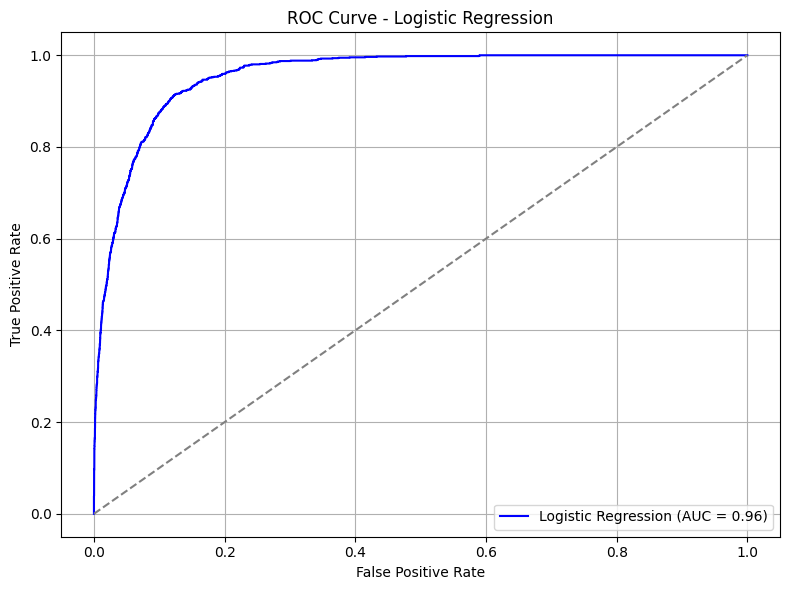

In [132]:
# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test_model, y_proba)
roc_auc = roc_auc_score(y_test_model, y_proba)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [133]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

def evaluate_rank_ks(y_true, y_pred_proba, n_bins=10, plot_ks=True):
    # Create a DataFrame with true and predicted values
    df = pd.DataFrame({
        'y_true': y_true,
        'y_score': y_pred_proba
    })

    # Create decile bins
    df['score_bin'] = pd.qcut(df['y_score'], q=n_bins, duplicates='drop')

    # Aggregate stats per bin
    grouped = df.groupby('score_bin', as_index=False).agg(
        total=('y_true', 'count'),
        bad=('y_true', 'sum'),
    )
    grouped['good'] = grouped['total'] - grouped['bad']
    
    # Cumulative sums
    grouped['cum_good'] = grouped['good'].cumsum()
    grouped['cum_bad'] = grouped['bad'].cumsum()
    grouped['cum_good_pct'] = grouped['cum_good'] / grouped['good'].sum()
    grouped['cum_bad_pct'] = grouped['cum_bad'] / grouped['bad'].sum()
    
    # KS statistic
    grouped['ks'] = np.abs(grouped['cum_good_pct'] - grouped['cum_bad_pct'])
    ks_stat = grouped['ks'].max()

    print("\n📊 Rank Ordering Table:")
    print(grouped[['score_bin', 'total', 'bad', 'good', 'cum_bad_pct', 'cum_good_pct', 'ks']])

    print(f"\n✅ KS Statistic: {ks_stat:.4f}")
    
    if plot_ks:
        # Plot KS curve
        plt.figure(figsize=(8, 5))
        plt.plot(grouped['cum_bad_pct'], label='Cumulative Bad Rate', color='red')
        plt.plot(grouped['cum_good_pct'], label='Cumulative Good Rate', color='green')
        plt.plot(grouped['ks'], label='KS Curve', color='blue', linestyle='--')
        plt.xlabel("Decile Bins")
        plt.ylabel("Cumulative Proportion")
        plt.title("KS Curve")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    return ks_stat, grouped


C:\Users\Admin\AppData\Local\Temp\ipykernel_10700\1145123982.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('score_bin', as_index=False).agg(



📊 Rank Ordering Table:
              score_bin  total  bad  good  cum_bad_pct  cum_good_pct   ks
0  (-0.000827, 0.00117]   1250    0  1250         0.00          0.11 0.11
1    (0.00117, 0.00345]   1250    0  1250         0.00          0.22 0.22
2    (0.00345, 0.00802]   1250    0  1250         0.00          0.33 0.33
3     (0.00802, 0.0169]   1249    2  1247         0.00          0.44 0.44
4      (0.0169, 0.0385]   1250    1  1249         0.00          0.55 0.55
5      (0.0385, 0.0927]   1250    7  1243         0.01          0.66 0.65
6       (0.0927, 0.211]   1249   14  1235         0.02          0.77 0.74
7        (0.211, 0.464]   1250   67  1183         0.08          0.87 0.79
8        (0.464, 0.832]   1250  264   986         0.32          0.96 0.64
9          (0.832, 1.0]   1250  753   497         1.00          1.00 0.00

✅ KS Statistic: 0.7877


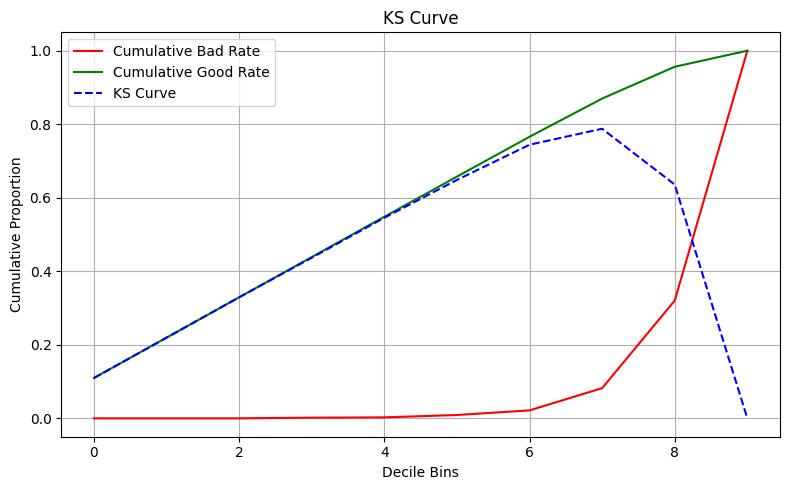

In [136]:
# After fitting your model and getting predicted probabilities:
y_pred_proba = final_model.predict_proba(X_test_model)[:, 1]
ks_statistic, rank_table = evaluate_rank_ks(y_test_model, y_pred_proba)
    

In [137]:
def evaluate_rank_ks(y_true, y_pred_proba, n_bins=10):
    import pandas as pd
    import numpy as np

    # Step 1: Create base DataFrame
    df = pd.DataFrame({
        'y_true': y_true,
        'y_score': y_pred_proba
    })

    # Step 2: Assign deciles (1 = highest score)
    df['decile'] = pd.qcut(df['y_score'], q=n_bins, labels=False, duplicates='drop') + 1
    df = df.sort_values(by='y_score', ascending=False)

    # Step 3: Aggregate per decile
    grouped = df.groupby('decile', as_index=False).agg(
        total=('y_true', 'count'),
        events=('y_true', 'sum')
    )
    grouped['non_events'] = grouped['total'] - grouped['events']
    grouped['event_rate'] = grouped['events'] / grouped['total']

    # Step 4: Cumulative stats
    grouped['cum_events'] = grouped['events'].cumsum()
    grouped['cum_non_events'] = grouped['non_events'].cumsum()
    grouped['cum_events_pct'] = grouped['cum_events'] / grouped['events'].sum()
    grouped['cum_non_events_pct'] = grouped['cum_non_events'] / grouped['non_events'].sum()
    grouped['ks'] = np.abs(grouped['cum_events_pct'] - grouped['cum_non_events_pct'])

    # Step 5: Final KS value
    ks_value = grouped['ks'].max()

    return ks_value, grouped


In [139]:
y_pred_proba = final_model.predict_proba(X_test_model)[:, 1]
ks_statistic, rank_table = evaluate_rank_ks(y_test_model, y_pred_proba)

print("✅ KS Statistic:", ks_statistic)
print("\n📊 Rank Table:")
rank_table


✅ KS Statistic: 0.7876681045822069

📊 Rank Table:


,decile,total,events,non_events,event_rate,cum_events,cum_non_events,cum_events_pct,cum_non_events_pct,ks
0,1,1250,0,1250,0.00,0,1250,0.00,0.11,0.11
1,2,1250,0,1250,0.00,0,2500,0.00,0.22,0.22
2,3,1250,0,1250,0.00,0,3750,0.00,0.33,0.33
3,4,1249,2,1247,0.00,2,4997,0.00,0.44,0.44
4,5,1250,1,1249,0.00,3,6246,0.00,0.55,0.55
5,6,1250,7,1243,0.01,10,7489,0.01,0.66,0.65
6,7,1249,14,1235,0.01,24,8724,0.02,0.77,0.74
7,8,1250,67,1183,0.05,91,9907,0.08,0.87,0.79
8,9,1250,264,986,0.21,355,10893,0.32,0.96,0.64
9,10,1250,753,497,0.60,1108,11390,1.00,1.00,0.00


Model Evaluation Note – KS Statistic
The model achieved a KS Statistic of 0.787, which indicates excellent discriminatory power. This means the model is highly effective at separating events (positives) from non-events (negatives).

The maximum KS value occurs at the 8th decile, implying that up to this point, the model captures the largest difference between cumulative event and non-event rates. Specifically, by the 8th decile:

The model successfully identified the vast majority of actual events (bad cases), and

It kept most non-events (good cases) in the lower deciles.

A KS value above 0.40 is generally considered good in binary classification tasks, especially in credit risk and fraud modeling. A KS of 0.787 reflects a highly robust model, capable of ranking and prioritizing risk effectively.

In [141]:
from sklearn.metrics import roc_auc_score

# Calculate AUC
auc = roc_auc_score(y_test_model, y_pred_proba)

# Calculate Gini
gini = 2 * auc - 1

print(f"✅ AUC: {auc:.4f}")
print(f"✅ Gini Coefficient: {gini:.4f}")


✅ AUC: 0.9561
✅ Gini Coefficient: 0.9123


✅ AUC (Area Under the ROC Curve): 0.95
AUC near 1.0 indicates that the model is very good at ranking positive instances higher than negatives, with very few classification errors.

✅ Gini Coefficient: 0.91
Since Gini is derived from AUC (Gini = 2 × AUC − 1), this value reaffirms the model's strong rank ordering capability. Gini > 0.6 is considered good in most scoring applications; 0.92+ is outstanding.

✅ Conclusion:
The model is well-calibrated and highly effective at risk separation. It ranks observations accurately, detects events with minimal overlap, and is suitable for high-stakes classification tasks such as credit scoring, fraud detection, or churn modeling.

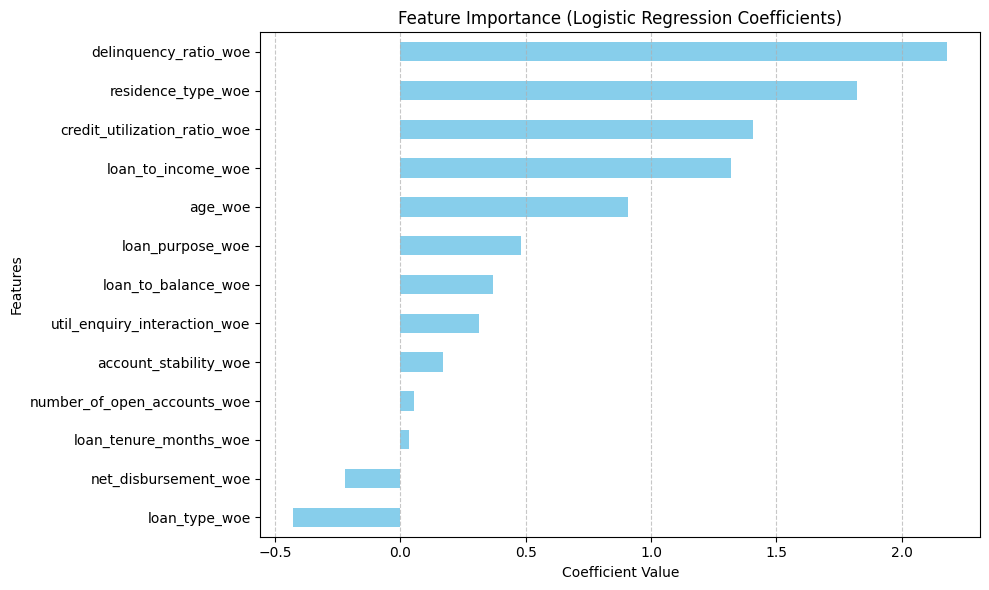

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract model coefficients
feature_importance = final_model.coef_[0]  # for binary classification

# Create a DataFrame of coefficients
coef_df = pd.DataFrame({
    'coefficients': feature_importance
}, index=X_test_model.columns)

# Sort by absolute value if you want strongest effects on top
coef_df = coef_df.sort_values(by='coefficients', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
coef_df['coefficients'].plot(kind='barh', color='skyblue')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, roc_auc_score
import optuna
import numpy as np
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

# -------------------------------
# Step 1: Ensure numeric (IMPORTANT for XGBoost)
# -------------------------------
X_train_model = X_train_model.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_model  = X_test_model.apply(pd.to_numeric, errors='coerce').fillna(0)

# -------------------------------
# Step 2: Sampling
# -------------------------------
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_model, y_train_model)

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_model, y_train_model)

# -------------------------------
# Step 3: Logistic Regression Tuning
# -------------------------------
log_reg = LogisticRegression(solver='saga', max_iter=10000, random_state=42)

param_dist_log = {
    'penalty': ['l1', 'l2'],
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.5, 0.9]
}

random_search_log = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist_log,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_log.fit(X_train_model, y_train_model)

# -------------------------------
# Step 4: XGBoost Tuning
# -------------------------------
xgb_tuned = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

param_dist_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0, 0.3]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train_model, y_train_model)

# -------------------------------
# Step 5: Optuna Tuning (FIXED — no leakage)
# -------------------------------
def objective(trial):

    C = trial.suggest_float('C', 1e-4, 1e2, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        tol=tol,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_model, y_train_model,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    )

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

best_params_logi = study.best_trial.params

final_model_logi = LogisticRegression(
    C=best_params_logi['C'],
    penalty=best_params_logi['penalty'],
    solver='liblinear' if best_params_logi['penalty']=='l1' else 'lbfgs',
    tol=best_params_logi['tol'],
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# -------------------------------
# Step 6: Model comparison
# -------------------------------
models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000), X_train_model, y_train_model),
    ("Random Forest", RandomForestClassifier(), X_train_model, y_train_model),
    ("XGBoost", XGBClassifier(eval_metric='logloss'), X_train_model, y_train_model),
    ("Tuned Logistic", random_search_log.best_estimator_, X_train_model, y_train_model),
    ("Tuned XGB", random_search_xgb.best_estimator_, X_train_model, y_train_model),
    ("Logistic (RUS)", LogisticRegression(max_iter=1000), X_train_rus, y_train_rus),
    ("Logistic (SMOTE)", LogisticRegression(max_iter=1000), X_train_smt, y_train_smt),
    ("Optuna Logistic", final_model_logi, X_train_model, y_train_model)
]

# -------------------------------
# Step 7: Evaluation
# -------------------------------
for name, model, X_tr, y_tr in models:

    print(f"\n===== {name} =====")

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_test_model)
    y_prob = model.predict_proba(X_test_model)[:, 1]

    print(classification_report(y_test_model, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test_model, y_prob))

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-05-03 19:53:46,798] A new study created in memory with name: no-name-af081fa1-8b7d-4ee1-a385-e43af57d16bb
[I 2026-05-03 19:53:47,040] Trial 0 finished with value: 0.9005820489536672 and parameters: {'C': 0.0003442124388641294, 'penalty': 'l1', 'tol': 0.0006338894301060998}. Best is trial 0 with value: 0.9005820489536672.
[I 2026-05-03 19:53:47,222] Trial 1 finished with value: 0.9579702760311873 and parameters: {'C': 0.006155771109913653, 'penalty': 'l2', 'tol': 0.003863248254782015}. Best is trial 1 with value: 0.9579702760311873.
[I 2026-05-03 19:53:47,587] Trial 2 finished with value: 0.9589222900660287 and parameters: {'C': 0.9032893466003492, 'penalty': 'l1', 'tol': 0.00011263005741884406}. 


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     11390
           1       0.74      0.50      0.59      1108

    accuracy                           0.94     12498
   macro avg       0.85      0.74      0.78     12498
weighted avg       0.93      0.94      0.93     12498

ROC-AUC: 0.9555645667394606

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     11390
           1       0.68      0.49      0.57      1108

    accuracy                           0.93     12498
   macro avg       0.81      0.73      0.77     12498
weighted avg       0.93      0.93      0.93     12498

ROC-AUC: 0.9470893699901426

===== XGBoost =====
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11390
           1       0.69      0.54      0.61      1108

    accuracy                           0.94  

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:53:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.95      0.98      0.97     11390
           1       0.74      0.50      0.59      1108

    accuracy                           0.94     12498
   macro avg       0.85      0.74      0.78     12498
weighted avg       0.93      0.94      0.93     12498

ROC-AUC: 0.9555615556745894

===== Tuned XGB =====
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11390
           1       0.73      0.53      0.62      1108

    accuracy                           0.94     12498
   macro avg       0.84      0.76      0.79     12498
weighted avg       0.94      0.94      0.94     12498

ROC-AUC: 0.9621895433640885

===== Logistic (RUS) =====
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     11390
           1       0.43      0.90      0.59      1108

    accuracy                           0.89     12498
   macro avg       0.

In [146]:
from sklearn.metrics import classification_report, roc_auc_score

reports = []

for name, model, X_tr, y_tr in models:

    print(f"\n📊 {name} Report:")

    # Train
    model.fit(X_tr, y_tr)

    # Predict
    y_pred = model.predict(X_test_model)
    y_prob = model.predict_proba(X_test_model)[:, 1]

    # Store report
    report = classification_report(y_test_model, y_pred, output_dict=True)
    report['roc_auc'] = roc_auc_score(y_test_model, y_prob)
    report['model'] = name

    reports.append(report)

    # Print nicely
    print(classification_report(y_test_model, y_pred))
    print(f"ROC-AUC: {report['roc_auc']:.4f}")


📊 Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     11390
           1       0.74      0.50      0.59      1108

    accuracy                           0.94     12498
   macro avg       0.85      0.74      0.78     12498
weighted avg       0.93      0.94      0.93     12498

ROC-AUC: 0.9556

📊 Random Forest Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     11390
           1       0.67      0.50      0.57      1108

    accuracy                           0.93     12498
   macro avg       0.81      0.74      0.77     12498
weighted avg       0.93      0.93      0.93     12498

ROC-AUC: 0.9459

📊 XGBoost Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11390
           1       0.69      0.54      0.61      1108

    accuracy                           0.94     12498
   macro avg       0.

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


              precision    recall  f1-score   support

           0       0.95      0.98      0.97     11390
           1       0.74      0.50      0.59      1108

    accuracy                           0.94     12498
   macro avg       0.85      0.74      0.78     12498
weighted avg       0.93      0.94      0.93     12498

ROC-AUC: 0.9556

📊 Tuned XGB Report:


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:54:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.96      0.98      0.97     11390
           1       0.73      0.53      0.62      1108

    accuracy                           0.94     12498
   macro avg       0.84      0.76      0.79     12498
weighted avg       0.94      0.94      0.94     12498

ROC-AUC: 0.9622

📊 Logistic (RUS) Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     11390
           1       0.43      0.90      0.59      1108

    accuracy                           0.89     12498
   macro avg       0.71      0.89      0.76     12498
weighted avg       0.94      0.89      0.90     12498

ROC-AUC: 0.9562

📊 Logistic (SMOTE) Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     11390
           1       0.43      0.90      0.58      1108

    accuracy                           0.89     12498
   macro avg       0.71      0.89      0.7

In [147]:
import pandas as pd

summary = []

for r in reports:
    summary.append({
        'Model': r['model'],
        'Precision_1': r['1']['precision'],
        'Recall_1': r['1']['recall'],
        'F1_1': r['1']['f1-score'],
        'ROC_AUC': r['roc_auc']
    })

summary_df = pd.DataFrame(summary).sort_values(by='ROC_AUC', ascending=False)

print("\n===== MODEL COMPARISON =====")
print(summary_df)


===== MODEL COMPARISON =====
                 Model  Precision_1  Recall_1  F1_1  ROC_AUC
4            Tuned XGB         0.73      0.53  0.62     0.96
2              XGBoost         0.69      0.54  0.61     0.96
7      Optuna Logistic         0.43      0.90  0.58     0.96
5       Logistic (RUS)         0.43      0.90  0.59     0.96
6     Logistic (SMOTE)         0.43      0.90  0.58     0.96
0  Logistic Regression         0.74      0.50  0.59     0.96
3       Tuned Logistic         0.74      0.50  0.59     0.96
1        Random Forest         0.67      0.50  0.57     0.95


In [153]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Loan Default Prediction")

run_ids = {}  # store run_id for later registration

for i, (name, model, X_tr, y_tr) in enumerate(models):

    report = reports[i]

    with mlflow.start_run(run_name=name) as run:

        # Train
        model.fit(X_tr, y_tr)

        # Log params
        mlflow.log_params({k: str(v) for k, v in model.get_params().items()})

        # Log metrics
        mlflow.log_metric("precision_1", report['1']['precision'])
        mlflow.log_metric("recall_1", report['1']['recall'])
        mlflow.log_metric("f1_1", report['1']['f1-score'])
        mlflow.log_metric("roc_auc", report['roc_auc'])

        # Input example
        input_example = X_test_model.iloc[:1]

        # 🔥 ALWAYS USE SAME ARTIFACT PATH
        if "XGB" in name:
            mlflow.xgboost.log_model(model, "model", input_example=input_example)
        else:
            mlflow.sklearn.log_model(model, "model", input_example=input_example)

        run_ids[name] = run.info.run_id

        print(f"✅ Logged: {name} | Run ID: {run.info.run_id}")

2026/05/03 20:27:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 20:27:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missin

✅ Logged: Logistic Regression | Run ID: 8e5c98829e52431fb7df253b390ce1a6
🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/222244129586907778/runs/8e5c98829e52431fb7df253b390ce1a6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/222244129586907778


2026/05/03 20:27:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 20:27:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missin

✅ Logged: Random Forest | Run ID: bb10036018954741a3af389880dd729e
🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/222244129586907778/runs/bb10036018954741a3af389880dd729e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/222244129586907778


2026/05/03 20:28:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


✅ Logged: XGBoost | Run ID: ac5dc471e35a4c3dae0fbc895da4921d
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/222244129586907778/runs/ac5dc471e35a4c3dae0fbc895da4921d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/222244129586907778


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
2026/05/03 20:28:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 20:28:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at in

✅ Logged: Tuned Logistic | Run ID: 253bcbc7ecf64ecea6570252a110acad
🏃 View run Tuned Logistic at: http://127.0.0.1:5000/#/experiments/222244129586907778/runs/253bcbc7ecf64ecea6570252a110acad
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/222244129586907778


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:28:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/05/03 20:28:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have miss

✅ Logged: Tuned XGB | Run ID: 4ab01cc2839a40898b4f3f82e83ada57
🏃 View run Tuned XGB at: http://127.0.0.1:5000/#/experiments/222244129586907778/runs/4ab01cc2839a40898b4f3f82e83ada57
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/222244129586907778


2026/05/03 20:28:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 20:28:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missin

✅ Logged: Logistic (RUS) | Run ID: ad41772ea7f54d4da444bd3813488e08
🏃 View run Logistic (RUS) at: http://127.0.0.1:5000/#/experiments/222244129586907778/runs/ad41772ea7f54d4da444bd3813488e08
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/222244129586907778


2026/05/03 20:28:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 20:28:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missin

✅ Logged: Logistic (SMOTE) | Run ID: a35139f8926648b486e45ef8ab7629cb
🏃 View run Logistic (SMOTE) at: http://127.0.0.1:5000/#/experiments/222244129586907778/runs/a35139f8926648b486e45ef8ab7629cb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/222244129586907778


2026/05/03 20:29:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 20:29:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missin

✅ Logged: Optuna Logistic | Run ID: 6b861ee0b5ad4d8298d942064841f6f9
🏃 View run Optuna Logistic at: http://127.0.0.1:5000/#/experiments/222244129586907778/runs/6b861ee0b5ad4d8298d942064841f6f9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/222244129586907778


# Register the Model

In [152]:
from mlflow import register_model

run_id = input("Enter Run ID: ")  # example: a685bd668f594153a6b28f5b3b6ac0ff

# ✅ Match the cleaned artifact_path used during logging
artifact_path = "Logistic_Regression_SMOTE_Tomek"

model_uri = f"runs:/{run_id}/{artifact_path}"

result = mlflow.register_model(
    model_uri=model_uri,
    name="Logistic Regression - SMOTE TONEK"  # Model Registry name
)

print("✅ Registered model:", result.name, "version:", result.version)


Enter Run ID:  6cdfc881819140d38d7e63e6cc867c46
Enter Model Name (exact):  Logistic (SMOTE)


Registered model 'Loan_Default_Model' already exists. Creating a new version of this model...


MlflowException: Unable to find a logged_model with artifact_path Logistic_SMOTE under run 6cdfc881819140d38d7e63e6cc867c46

In [161]:
from mlflow import register_model

registered_versions = {}

for name, run_id in run_ids.items():

    model_uri = f"runs:/{run_id}/model"

    result = register_model(
        model_uri=model_uri,
        name="Loan_Default_Model"
    )

    registered_versions[name] = result.version

    print(f"✅ {name} registered → Version {result.version}")

Successfully registered model 'Loan_Default_Model'.


RestException: RESOURCE_DOES_NOT_EXIST: Run not found

In [158]:
import dagshub

dagshub.init(
    repo_owner="Krushang010",
    repo_name="Credit-Default-Risk-Prediction",
    mlflow=True
)

Initialized MLflow to track repo "Krushang010/Credit-Default-Risk-Prediction"

Repository Krushang010/Credit-Default-Risk-Prediction initialized!

In [160]:
import dagshub
import mlflow

dagshub.init(
    repo_owner="krushang010",
    repo_name="Credit-Default-Risk-Prediction",
    mlflow=True
)

# 🔥 FORCE MLflow to use DagsHub
mlflow.set_tracking_uri("https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow")

mlflow.set_experiment("Loan Default Prediction")

Initialized MLflow to track repo "krushang010/Credit-Default-Risk-Prediction"

Repository krushang010/Credit-Default-Risk-Prediction initialized!

2026/05/03 21:48:54 INFO mlflow.tracking.fluent: Experiment with name 'Loan Default Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/66e624e00a404af0bf408285e0bf2e7c', creation_time=1777825134906, experiment_id='0', last_update_time=1777825134906, lifecycle_stage='active', name='Loan Default Prediction', tags={}, trace_location=None, workspace='default'>

In [181]:
import mlflow
import mlflow.sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

for name, model, X_tr, y_tr in models:

    with mlflow.start_run(run_name=name):

        # ===============================
        # Train
        # ===============================
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_test_model)
        y_prob = model.predict_proba(X_test_model)[:, 1]

        report = classification_report(y_test_model, y_pred, output_dict=True)

        # ===============================
        # 1. PARAMETERS
        # ===============================
        mlflow.log_params({k: str(v) for k, v in model.get_params().items()})

        # ===============================
        # 2. METRICS (CORE)
        # ===============================
        mlflow.log_metric("precision_1", report['1']['precision'])
        mlflow.log_metric("recall_1", report['1']['recall'])
        mlflow.log_metric("f1_1", report['1']['f1-score'])

        mlflow.log_metric("precision_0", report['0']['precision'])
        mlflow.log_metric("recall_0", report['0']['recall'])

        mlflow.log_metric("accuracy", report['accuracy'])
        mlflow.log_metric("f1_macro", report['macro avg']['f1-score'])
        mlflow.log_metric("f1_weighted", report['weighted avg']['f1-score'])

        roc_auc = roc_auc_score(y_test_model, y_prob)
        mlflow.log_metric("roc_auc", roc_auc)

        # ===============================
        # 3. EXTRA BUSINESS METRICS
        # ===============================
        # KS Statistic
        fpr, tpr, thresholds = roc_curve(y_test_model, y_prob)
        ks = np.max(tpr - fpr)
        mlflow.log_metric("ks_statistic", ks)

        # Precision-Recall AUC
        precision, recall, _ = precision_recall_curve(y_test_model, y_prob)
        pr_auc = np.trapz(precision, recall)
        mlflow.log_metric("pr_auc", pr_auc)

        # ===============================
        # 4. CONFUSION MATRIX (ARTIFACT)
        # ===============================
        cm = confusion_matrix(y_test_model, y_pred)

        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        plt.savefig("confusion_matrix.png")
        mlflow.log_artifact("confusion_matrix.png")
        plt.close()

        # ===============================
        # 5. ROC CURVE (ARTIFACT)
        # ===============================
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
        plt.plot([0,1], [0,1], linestyle="--")
        plt.title(f"ROC Curve - {name}")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.legend()

        plt.savefig("roc_curve.png")
        mlflow.log_artifact("roc_curve.png")
        plt.close()

        # ===============================
        # 6. MODEL (AUTO REGISTER)
        # ===============================
        mlflow.sklearn.log_model(
            sk_model=model,
            name="Loan_Default_Model"
        )

        print(f"✅ {name} logged completely")

2026/05/03 22:14:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logistic Regression logged completely
🏃 View run Logistic Regression at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0/runs/6c33b1b74d4c49c390f48c3fd48ee148
🧪 View experiment at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0


2026/05/03 22:15:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random Forest logged completely
🏃 View run Random Forest at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0/runs/4c6b75527fbe4c5b87b8b8106f50abc6
🧪 View experiment at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0


2026/05/03 22:16:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ XGBoost logged completely
🏃 View run XGBoost at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0/runs/6ca083d6b24f46088b17c8481cd8f25e
🧪 View experiment at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
2026/05/03 22:17:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Tuned Logistic logged completely
🏃 View run Tuned Logistic at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0/runs/fd9afad0507e4f9b898c8d987b6eca5a
🧪 View experiment at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:17:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/05/03 22:17:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Tuned XGB logged completely
🏃 View run Tuned XGB at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0/runs/e0d045c7a24f4a96a2f9cfd57764a1ef
🧪 View experiment at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0


2026/05/03 22:18:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logistic (RUS) logged completely
🏃 View run Logistic (RUS) at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0/runs/d558e3e2762f4f3abdcb8de9f9451190
🧪 View experiment at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0


2026/05/03 22:19:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logistic (SMOTE) logged completely
🏃 View run Logistic (SMOTE) at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0/runs/a94426d0b6094617ab56bf50bb5d3aaa
🧪 View experiment at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0


2026/05/03 22:19:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Optuna Logistic logged completely
🏃 View run Optuna Logistic at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0/runs/b0e52c5b25b04ca287b86ba1a89e9466
🧪 View experiment at: https://dagshub.com/Krushang010/Credit-Default-Risk-Prediction.mlflow/#/experiments/0


In [182]:
# save_artifact.py
from joblib import dump
import os

os.makedirs("artifacts", exist_ok=True)

model_data = {
    "model": final_model_logi,
    "features": X_train_model.columns.tolist(),
    "woe_cont_dict": woe_cont_dict,
    "bin_edges_dict": bin_edges_dict,
    "woe_cat_dict": woe_cat_dict,  # if used
}

dump(model_data, "artifacts/model_data.joblib")
print("✅ Saved model_data.joblib")

✅ Saved model_data.joblib


In [183]:
X_train_model.columns.tolist()

['credit_utilization_ratio_woe',
 'delinquency_ratio_woe',
 'loan_to_income_woe',
 'loan_tenure_months_woe',
 'net_disbursement_woe',
 'age_woe',
 'number_of_open_accounts_woe',
 'loan_purpose_woe',
 'residence_type_woe',
 'loan_type_woe',
 'util_enquiry_interaction_woe',
 'account_stability_woe',
 'loan_to_balance_woe']

In [ ]:
from joblib import dump

model_data = {
    'model': final_model_logi,
    'features': X_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale_': col_to_scale
}
dump(model_data ,'artifacts/model_data.joblib')


